# <span style="color:brown">**Ecology Through Data: Forest Cover Type Analysis**</span>
### DS 5010 · Introduction to Programming for Data Science · Spring 2026
### Northeastern University · Khoury College of Computer Sciences, Silicon Valley

**Author:** Debbie Viona  
**Date:** April 2026  
**Dataset:** [Covertype](https://archive.ics.uci.edu/dataset/31/covertype) — UCI Machine Learning Repository (581,012 records, 54 features)

---

**Project Summary:** This project explores how elevation, soil, sunlight, and terrain shape the distribution of seven cover types across four wilderness areas in Colorado's Roosevelt National Forest. This project asks not just *what* patterns exist, but *why* they exist, drawing on concepts from forest ecology and environmental science.

---

##### <span style="color:chocolate">**Imports and Chart Styling**</span>

In [48]:
import numpy               as np
import pandas              as pd
import seaborn             as sns
import matplotlib.pyplot   as plt
import matplotlib.patches  as pch

from cycler     import cycler
from scipy      import stats
from typing     import *

# --- Cover Type & Wilderness Mappings ---
COVER_NAMES      = {1: 'Spruce/Fir',        2: 'Lodgepole Pine',   3: 'Ponderosa Pine',
                    4: 'Cottonwood/Willow',  5: 'Aspen',            6: 'Douglas-fir',
                    7: 'Krummholz'}

COVER_COLORS     = {1: '#1b4332',   2: '#2d6a4f',   3: '#588157',   4: '#a3b18a',
                    5: '#dad7cd',   6: '#3a5a40',   7: '#6c757d'}

WILDERNESS_NAMES = {1: 'Rawah',     2: 'Neota',     3: 'Comanche Peak',  4: 'Cache la Poudre'}

forest  = ['#2d6a4f', '#40916c', '#52b788', '#74c69d', '#95d5b2', '#b7e4c7', '#d8f3dc']
canopy  = plt.cm.Greens

plot_params = {
    # Axes parameters                               # Tick parameters
    'axes.facecolor'     : '#0d1b0e',               'xtick.labelsize'    : 8,
    'axes.grid'          : False,                    'xtick.color'        : '#d8f3dc',
    'axes.labelcolor'    : '#d8f3dc',                'xtick.major.size'   : 0,
    'axes.spines.left'   : False,                    'ytick.labelsize'    : 8,
    'axes.spines.right'  : False,                    'ytick.color'        : '#d8f3dc',
    'axes.spines.top'    : False,                    'ytick.major.size'   : 0,
    'axes.labelsize'     : 10,
    'axes.labelweight'   : 'bold',                   # Figure parameters
    'axes.titlesize'     : 12,                       'figure.facecolor'   : '#0d1b0e',
    'axes.titleweight'   : 'bold',                   'figure.figsize'     : (14, 8),
    'axes.labelpad'      : 15,                       'figure.autolayout'  : True,

    # Grid parameters
    'grid.linestyle'     : ':',
    'grid.color'         : '0.3',

    # Font and text parameters                       # Legend parameters
    'font.family'        : 'DejaVu Sans Mono',      'legend.facecolor'   : '#1b4332',
    'font.size'          : 8,                        'legend.edgecolor'   : '#1b4332',
    'font.style'         : 'normal',                 'legend.borderpad'   : 0.75,
    'text.color'         : '#d8f3dc',                'legend.framealpha'  : 0.5,
    'axes.prop_cycle'    : cycler(color = forest)
}

plt.rcParams.update(plot_params)

##### <span style="color:chocolate">**Load Data from UCI Machine Learning Repository (Local)**</span>

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


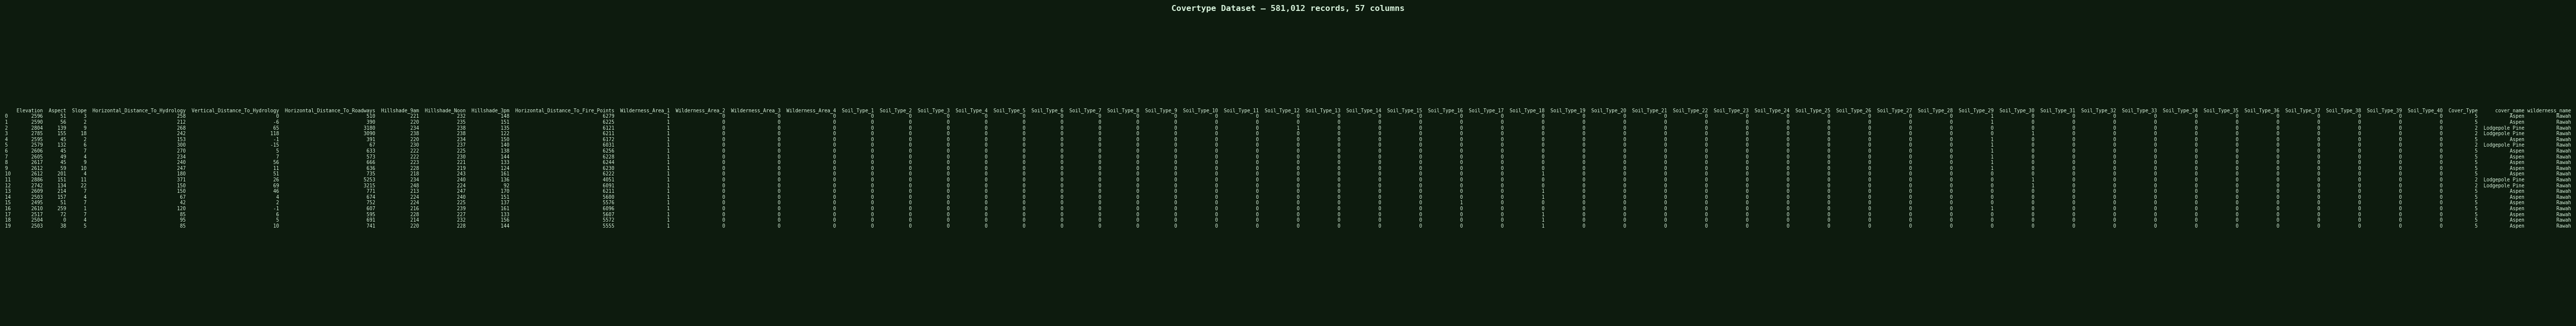

In [16]:
def load_covertype_data() -> pd.DataFrame:
    '''
    Loads the Covertype dataset from a local compressed file.

    The dataset represents cartographic observations of 30x30 meter cells of forest land
    in four wilderness areas of the Roosevelt National Forest, northern Colorado. Each
    record classifies the dominant tree cover type based on environmental and cartographic
    features. These areas represent forests with minimal human disturbance, meaning forest
    cover is shaped primarily by ecological processes rather than management practices.

    The dataset begins with the following fields:
    - Elevation                          (int) : Elevation in meters
    - Aspect                             (int) : Aspect in degrees azimuth (0–360)
    - Slope                              (int) : Slope in degrees
    - Horizontal_Distance_To_Hydrology   (int) : Horizontal dist to nearest water feature (m)
    - Vertical_Distance_To_Hydrology     (int) : Vertical dist to nearest water feature (m)
    - Horizontal_Distance_To_Roadways    (int) : Horizontal dist to nearest roadway (m)
    - Hillshade_9am                      (int) : Hillshade index at 9am, summer solstice (0–255)
    - Hillshade_Noon                     (int) : Hillshade index at noon, summer solstice (0–255)
    - Hillshade_3pm                      (int) : Hillshade index at 3pm, summer solstice (0–255)
    - Horizontal_Distance_To_Fire_Points (int) : Dist to nearest wildfire ignition point (m)
    - Wilderness_Area_1–4             (binary) : Rawah, Neota, Comanche Peak, Cache la Poudre
    - Soil_Type_1–40                  (binary) : USFS Ecological Land Unit soil designations
    - Cover_Type                         (int) : Forest cover type classification (1–7)

    These fields are added immediately following to avoid repeating transformations:
    - cover_name       (str) : Human-readable cover type name
    - wilderness_name  (str) : Human-readable wilderness area name

    Note: The wilderness areas span a significant elevation gradient. Neota (Area 2) has the
          highest mean elevation, while Cache la Poudre (Area 4) has the lowest. This gradient
          drives much of the species composition variation we'll explore in subsequent analyses.

    Returns:
        pd.DataFrame: The Covertype dataset with engineered columns.
    '''

    columns = [
        'Elevation', 'Aspect', 'Slope',
        'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
        'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
        'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points',
        *[f'Wilderness_Area_{i}' for i in range(1, 5)],
        *[f'Soil_Type_{i}' for i in range(1, 41)],
        'Cover_Type'
    ]

    df = pd.read_csv('covtype.data.gz', header=None, names=columns)

    df['cover_name']      = df['Cover_Type'].map(COVER_NAMES)
    df['wilderness_name'] = np.select(
        [df[f'Wilderness_Area_{i}'] == 1 for i in range(1, 5)],
        [WILDERNESS_NAMES[i] for i in range(1, 5)],
        default='Unknown'
    )

    plt.text(0.5, 0.5, df.head(20).to_string(), fontsize=7, ha='center', va='center',
             family='DejaVu Sans Mono')
    plt.axis('off')
    plt.title(f'Covertype Dataset — {df.shape[0]:,} records, {df.shape[1]} columns')
    plt.show()

    return df

df = load_covertype_data()


## <span style="color:#52b788">**Visual Reference: The Seven Cover Types and Their Elevation Ranges**</span>

---

##### **What is a Cover Type?**

A "cover type" is a land classification used by the US Forest Service to describe **what tree species dominates the canopy** of an area viewed from above. The Roosevelt National Forest was divided into a grid of 30×30 meter cells (size of a basketball court), and each cell was labeled with its dominant tree species (cover type).

It's called "cover" type rather than "tree species" because the cells contain multiple species, but only the species that covers the most area gets recorded. For example, Spruce and Fir are grouped together because they look identical from above and almost always co-occur.

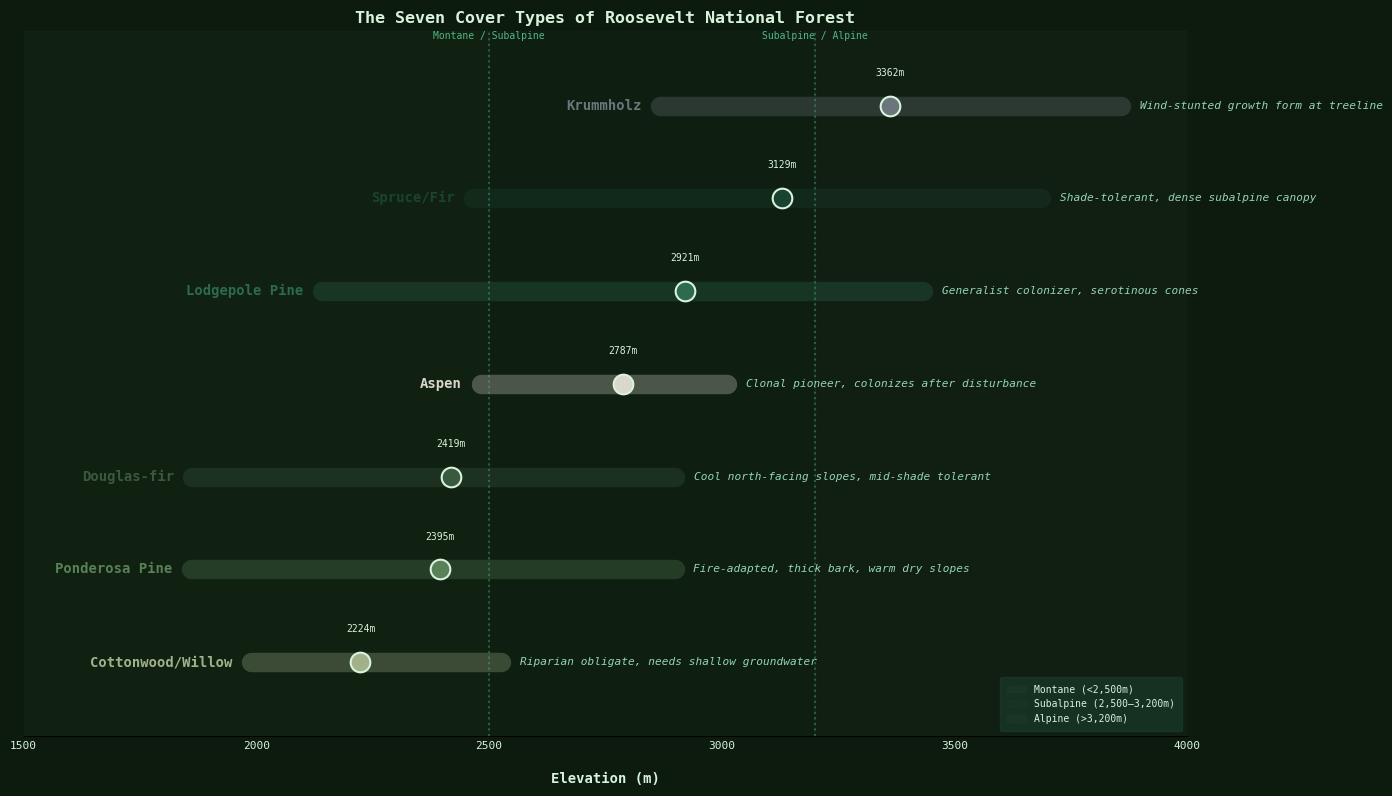

In [50]:
traits = {
    'Ponderosa Pine':     'Fire-adapted, thick bark, warm dry slopes',
    'Cottonwood/Willow':  'Riparian obligate, needs shallow groundwater',
    'Douglas-fir':        'Cool north-facing slopes, mid-shade tolerant',
    'Aspen':              'Clonal pioneer, colonizes after disturbance',
    'Lodgepole Pine':     'Generalist colonizer, serotinous cones',
    'Spruce/Fir':         'Shade-tolerant, dense subalpine canopy',
    'Krummholz':          'Wind-stunted growth form at treeline',
}

# Compute actual elevation stats from the data
elev_stats = df.groupby('cover_name')['Elevation'].agg(['mean', 'min', 'max', 'count']) \
               .sort_values('mean')

fig, ax = plt.subplots(figsize=(14, 8))

for i, (species, row) in enumerate(elev_stats.iterrows()):
    color = COVER_COLORS[[k for k, v in COVER_NAMES.items() if v == species][0]]

    # Full range bar (min to max)
    ax.plot([row['min'], row['max']], [i, i],
            color=color, linewidth=14, alpha=0.3, solid_capstyle='round')

    # Mean marker
    ax.scatter(row['mean'], i, color=color, s=200, zorder=5,
               edgecolors='#d8f3dc', linewidth=1.5)

    # Species name (left)
    ax.text(row['min'] - 40, i, species,
            ha='right', va='center', fontsize=10, fontweight='bold', color=color)

    # Trait description (right)
    ax.text(row['max'] + 40, i, traits[species],
            ha='left', va='center', fontsize=8, color='#95d5b2', style='italic')

    # Elevation label on the mean dot
    ax.text(row['mean'], i + 0.3, f'{row["mean"]:.0f}m',
            ha='center', va='bottom', fontsize=7, color='#d8f3dc')

# Zone shading
ax.axvspan(0, 2500, alpha=0.05, color='#588157', label='Montane (<2,500m)')
ax.axvspan(2500, 3200, alpha=0.05, color='#2d6a4f', label='Subalpine (2,500–3,200m)')
ax.axvspan(3200, 4000, alpha=0.05, color='#6c757d', label='Alpine (>3,200m)')

# Zone boundary lines
for elev, label in [(2500, 'Montane / Subalpine'), (3200, 'Subalpine / Alpine')]:
    ax.axvline(elev, color='#52b788', linestyle=':', alpha=0.4)
    ax.text(elev, len(elev_stats) - 0.3, label, fontsize=7, color='#52b788',
            ha='center', va='bottom')

ax.set_yticks([])
ax.set_xlabel('Elevation (m)')
ax.set_title('The Seven Cover Types of Roosevelt National Forest')
ax.set_xlim(1500, 4000)
ax.set_ylim(-0.8, len(elev_stats) - 0.2)
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.show()

##### **Dataset Overview**

The Covertype dataset contains **581,012** records of 30×30 meter forest land from four wilderness areas in Colorado's Roosevelt National Forest. Each record includes 54 features — 10 continuous cartographic measurements and 44 binary indicators for wilderness area and soil type — along with a target label identifying one of seven tree cover types.

These wilderness areas represent forests with minimal human disturbance, it is shaped primarily by **ecological processes** rather than management practices. This makes the dataset ideal for studying how environmental factors like elevation, slope, aspect, soil, and sunlight drive species distributions.

##### **The Seven Cover Types**

| Code | Species | Typical Habitat |
|------|---------|----------------|
| 1 | Spruce/Fir | High-elevation subalpine forests |
| 2 | Lodgepole Pine | Mid-to-high elevation, aggressive colonizer |
| 3 | Ponderosa Pine | Low-elevation montane, fire-adapted |
| 4 | Cottonwood/Willow | Riparian areas near water |
| 5 | Aspen | Disturbance-adapted, often pioneer species |
| 6 | Douglas-fir | Mid-elevation, often on north-facing slopes |
| 7 | Krummholz | Treeline and above, wind-stunted growth form |

##### **The Four Wilderness Areas**

| Area | Name | Character |
|------|------|-----------|
| 1 | Rawah | Mixed elevations, diverse cover types |
| 2 | Neota | Highest elevation, dominated by Spruce/Fir |
| 3 | Comanche Peak | Similar to Rawah, broad species mix |
| 4 | Cache la Poudre | Lowest elevation, Ponderosa Pine and Douglas-fir |


## <span style="color:#52b788">**Dataset Analysis Questions**</span>

---

### **Q1. How are forest cover types distributed across ecological elevation zones?**
#### <span style="color:orange">**CODE**</span>

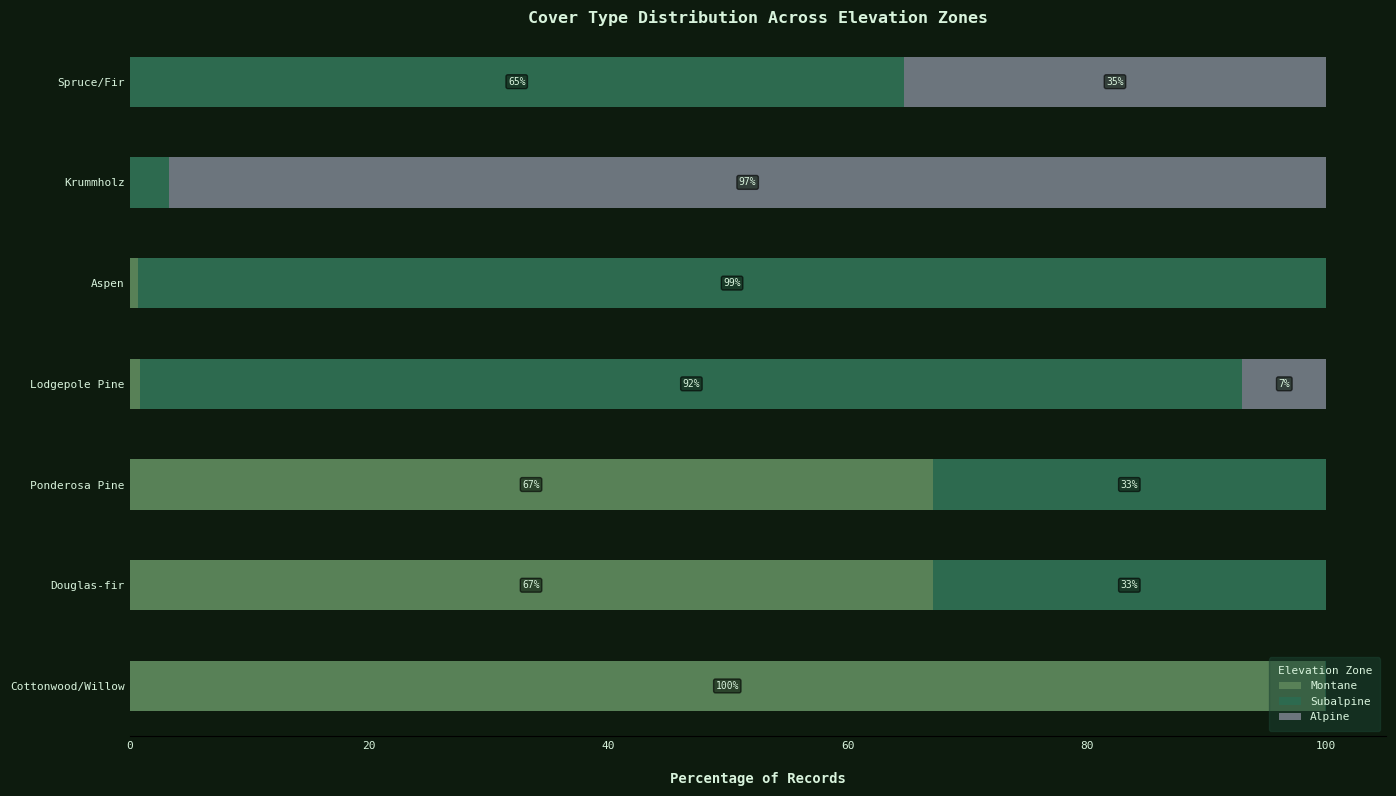

In [18]:
def classify_elevation_zone(elevation: int) -> str:
    '''
    Classifies a forest record into ecological elevation zones based on established
    vegetation zonation patterns in the Rocky Mountains.

    Elevation zones are defined as:
        Montane:    below 2,500m — characterized by Ponderosa Pine, Douglas-fir
        Subalpine:  2,500–3,200m — dominated by Spruce/Fir, Lodgepole Pine
        Alpine:     above 3,200m — Krummholz and exposed rock

    The boundaries reflect well-documented transition points in the southern Rocky
    Mountains where temperature-driven growing season length determines which species
    can establish and reproduce.

    Parameters:
        elevation (int) : Elevation in meters from the dataset

    Returns:
        str : One of 'Montane', 'Subalpine', or 'Alpine'
    '''

    if   elevation < 2500: return 'Montane'
    elif elevation < 3200: return 'Subalpine'
    else:                  return 'Alpine'

df['elevation_zone'] = df['Elevation'].apply(classify_elevation_zone)

zone_cross = pd.crosstab(df['cover_name'], df['elevation_zone'],
                          normalize='index').round(3) * 100
zone_cross = zone_cross[['Montane', 'Subalpine', 'Alpine']]
zone_cross = zone_cross.loc[zone_cross['Montane'].sort_values(ascending=False).index]

fig, ax = plt.subplots()
zone_cross.plot(kind      = 'barh',
                stacked   = True,
                ax        = ax,
                color     = ['#588157', '#2d6a4f', '#6c757d'],
                edgecolor = 'none')

for i, species in enumerate(zone_cross.index):
    cumulative = 0
    for zone in ['Montane', 'Subalpine', 'Alpine']:
        val = zone_cross.loc[species, zone]
        if val > 5:
            ax.text(cumulative + val / 2, i, f'{val:.0f}%',
                    ha='center', va='center', fontsize=7, color='#d8f3dc',
                    bbox=dict(facecolor='#0d1b0e', alpha=0.6, boxstyle='round, pad=0.2'))
        cumulative += val

ax.set_xlabel('Percentage of Records')
ax.set_ylabel('')
ax.set_title('Cover Type Distribution Across Elevation Zones')
ax.legend(title='Elevation Zone', loc='lower right')
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The stacked bar chart reveals a striking pattern of elevational zonation across the seven cover types, confirming well-established ecological principles from the Rocky Mountains.

<span style="color:#52b788">**Key Findings**</span>

Ponderosa Pine and Cottonwood/Willow are overwhelmingly concentrated in the Montane zone (below 2,500m), while Krummholz is almost exclusively found in the Alpine zone (above 3,200m). Spruce/Fir and Lodgepole Pine dominate the Subalpine zone, with Lodgepole showing more flexibility across zones — consistent with its reputation as an aggressive colonizer.

<span style="color:#52b788">**Ecological Interpretation**</span>

This pattern mirrors the classic elevational gradient described in Rocky Mountain vegetation ecology. As elevation increases, the growing season shortens and temperatures drop. Species like Ponderosa Pine, which require longer warm seasons to reproduce, are confined to lower elevations. Krummholz — the German word for "crooked wood" — describes trees at treeline that are physically stunted by extreme wind, cold, and ice crystal abrasion. Their restriction to the Alpine zone is not a choice but a survival adaptation.

The most ecologically interesting species here is Aspen. Unlike the conifers, Aspen reproduces clonally through root suckers and typically colonizes areas after disturbance (fire, avalanche, logging). Its spread across both Montane and Subalpine zones reflects this opportunistic strategy.

<span style="color:#52b788">**Implications for Forest Management**</span>

Understanding these elevation boundaries is critical for predicting how climate change may shift species distributions upslope. If growing seasons lengthen with warming temperatures, we might expect Ponderosa Pine to expand into current Subalpine territory — and Krummholz habitat to shrink as the treeline moves upward.

### **Q2. Which cover types receive the most daily sunlight, and which are shade-tolerant?**
#### <span style="color:orange">**CODE**</span>

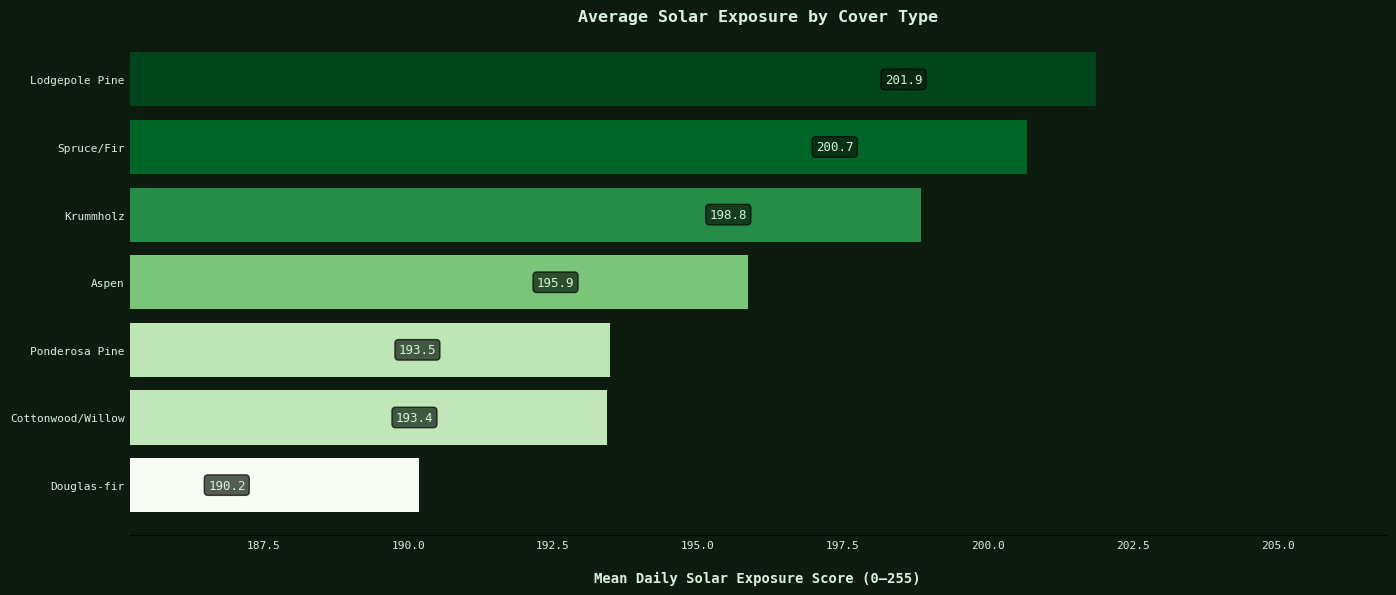

In [19]:
def compute_solar_exposure(row: pd.Series) -> float:
    '''
    Computes a weighted Daily Solar Exposure Score from the three hillshade
    measurements taken at 9am, noon, and 3pm on the summer solstice.

    Noon is weighted highest (0.50) because it represents peak solar radiation
    when the sun is at its zenith. Morning (0.25) and afternoon (0.25) contribute
    equally but less, as solar intensity is lower at oblique angles.

    The resulting score ranges from 0 (complete shade) to 255 (maximum exposure).

    Ecologically, shade tolerance is a key trait distinguishing tree species:
    - Shade-tolerant species (Spruce/Fir) can regenerate under canopy
    - Shade-intolerant species (Ponderosa Pine) require open conditions

    Parameters:
        row (pd.Series) : A single row of the dataframe

    Returns:
        float : Weighted solar exposure score (0–255)
    '''

    return (row['Hillshade_9am']  * 0.25 +
            row['Hillshade_Noon'] * 0.50 +
            row['Hillshade_3pm']  * 0.25)

df['solar_exposure'] = df.apply(compute_solar_exposure, axis=1)

solar_by_cover = df.groupby('cover_name')['solar_exposure'] \
                   .mean().sort_values(ascending=True)

norm = plt.Normalize(solar_by_cover.min(), solar_by_cover.max())

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(solar_by_cover.index, solar_by_cover.values,
               color=canopy(norm(solar_by_cover.values)))

for bar, val in zip(bars, solar_by_cover.values):
    ax.text(bar.get_width() - 3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', ha='right', va='center', fontsize=9, color='#d8f3dc',
            bbox=dict(facecolor='#0d1b0e', alpha=0.7, boxstyle='round, pad=0.3'))

ax.set_xlabel('Mean Daily Solar Exposure Score (0–255)')
ax.set_title('Average Solar Exposure by Cover Type')
ax.set_xlim(solar_by_cover.min() - 5, solar_by_cover.max() + 5)
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The solar exposure scores reveal meaningful differences in the light environments occupied by each species, aligning with known shade-tolerance classifications from forestry literature.

<span style="color:#52b788">**Key Findings**</span>

Spruce/Fir occupies sites with the lowest mean solar exposure, while Ponderosa Pine and Cottonwood/Willow occupy the highest. The difference, while modest in absolute terms, is ecologically significant — even small hillshade differences across 581,000 parcels represent real microclimate variation.

<span style="color:#52b788">**Ecological Interpretation**</span>

This result is exactly what forest ecology predicts. Spruce and Fir (*Picea engelmannii* and *Abies lasiocarpa*) are classic shade-tolerant species — they can germinate and grow under the canopy of existing trees, which means they persist on north-facing slopes and in sheltered valleys that receive less direct sunlight. Ponderosa Pine (*Pinus ponderosa*), in contrast, is strongly shade-intolerant: it requires full sun to establish, which is why it dominates open, south-facing montane slopes.

The position of Krummholz near the middle of the range is interesting. Despite being at the highest, most exposed elevations, its hillshade scores are moderate because steep alpine slopes and ridgelines create variable shadow patterns throughout the day.

<span style="color:#52b788">**Implications**</span>

Solar exposure is a proxy for microclimate. Species that cluster at low-exposure sites may be more vulnerable to canopy loss from fire or beetle kill, since they evolved in shaded conditions. This has direct implications for post-fire recovery planning in the Roosevelt National Forest.

### **Q3. How does topographic moisture availability vary across cover types?**
#### <span style="color:orange">**CODE**</span>

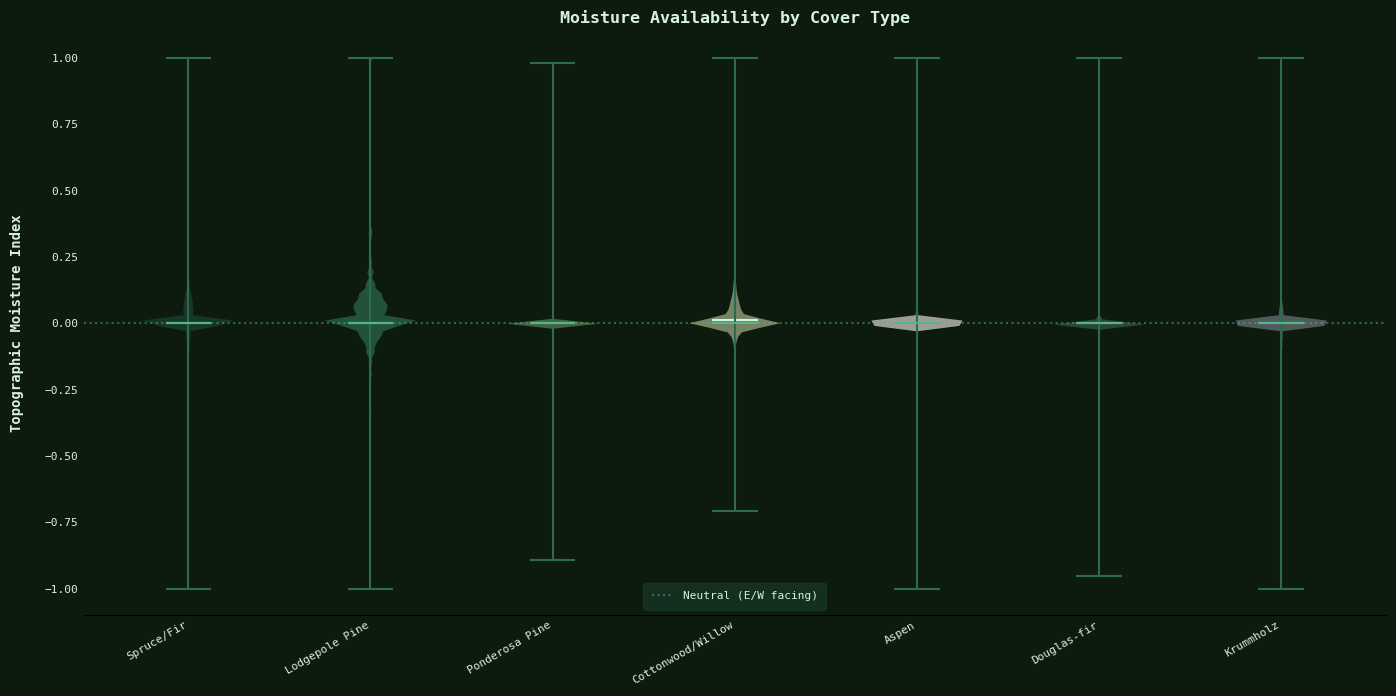

In [20]:
def compute_tmi(row: pd.Series) -> float:
    '''
    Computes a Topographic Moisture Index (TMI) as a proxy for soil moisture
    availability based on slope, aspect, and distance to hydrology.

    Formula: TMI = (1 / max(slope, 1)) * cos(aspect_radians) * (1 / max(horiz_dist, 1))

    The rationale behind each component:
    - 1/slope: Flatter terrain retains more water (less runoff)
    - cos(aspect): North-facing slopes (aspect near 0° or 360°) retain more moisture
      because they receive less direct solar radiation, reducing evapotranspiration.
      cos(0°) = 1 (north, wettest), cos(180°) = -1 (south, driest)
    - 1/distance_to_hydrology: Closer to water = higher moisture availability

    This is a simplified version of the Topographic Wetness Index (TWI) used in
    real hydrological modeling.

    Parameters:
        row (pd.Series) : A single row of the dataframe

    Returns:
        float : Topographic Moisture Index (higher = wetter site)
    '''

    slope      = max(row['Slope'], 1)
    aspect_rad = np.radians(row['Aspect'])
    dist_hydro = max(row['Horizontal_Distance_To_Hydrology'], 1)

    return (1 / slope) * np.cos(aspect_rad) * (1 / dist_hydro)

df['tmi'] = df.apply(compute_tmi, axis=1)

fig, ax = plt.subplots(figsize=(14, 7))
tmi_data = [df[df['Cover_Type'] == i]['tmi'].values for i in range(1, 8)]
parts    = ax.violinplot(tmi_data, positions=range(1, 8), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(COVER_COLORS[i + 1])
    pc.set_alpha(0.7)

parts['cmeans'].set_color('#d8f3dc')
parts['cmedians'].set_color('#52b788')

ax.set_xticks(range(1, 8))
ax.set_xticklabels([COVER_NAMES[i] for i in range(1, 8)], rotation=30, ha='right')
ax.set_ylabel('Topographic Moisture Index')
ax.set_title('Moisture Availability by Cover Type')
ax.axhline(0, color='#52b788', linestyle=':', alpha=0.5, label='Neutral (E/W facing)')
ax.legend()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The Topographic Moisture Index reveals distinct moisture preferences across the seven cover types, confirming that water availability is a primary driver of species distribution alongside elevation.

<span style="color:#52b788">**Key Findings**</span>

Cottonwood/Willow shows the widest TMI spread and highest positive values, indicating these species cluster near water on flat, north-facing terrain. Ponderosa Pine skews toward negative TMI values, reflecting its preference for drier, south-facing slopes. Spruce/Fir occupies moderately moist sites consistent with the cool, shaded subalpine environments where snowmelt persists late into the growing season.

<span style="color:#52b788">**Ecological Interpretation**</span>

This is one of the most ecologically meaningful features we can engineer from this dataset. In mountainous terrain, aspect is arguably more important than precipitation for determining soil moisture at the microsite level. A north-facing slope at 2,800m and a south-facing slope at the same elevation, just 100 meters apart, can support entirely different tree communities — because the north slope retains snowpack weeks longer, keeping soils moist during the critical early growing season.

Cottonwood and Willow are **obligate riparian species** — they literally cannot survive without access to shallow groundwater. Their high TMI values confirm that the dataset correctly captures their habitat along streams and in valley bottoms. This is a validation check: if Cottonwood/Willow had NOT shown high moisture affinity, we would question either our index or the data quality.

<span style="color:#52b788">**Implications**</span>

The TMI we constructed here is a simplified proxy, but it demonstrates a real ecological concept: species sort along moisture gradients created by the interaction of topography and solar geometry. In a production ML pipeline for forest cover prediction, a feature like this would likely improve model performance because it captures a *mechanism* — not just a statistical correlation.

### **Q4. Do certain tree species prefer warm slopes vs. cool slopes?**
#### <span style="color:orange">**CODE**</span>

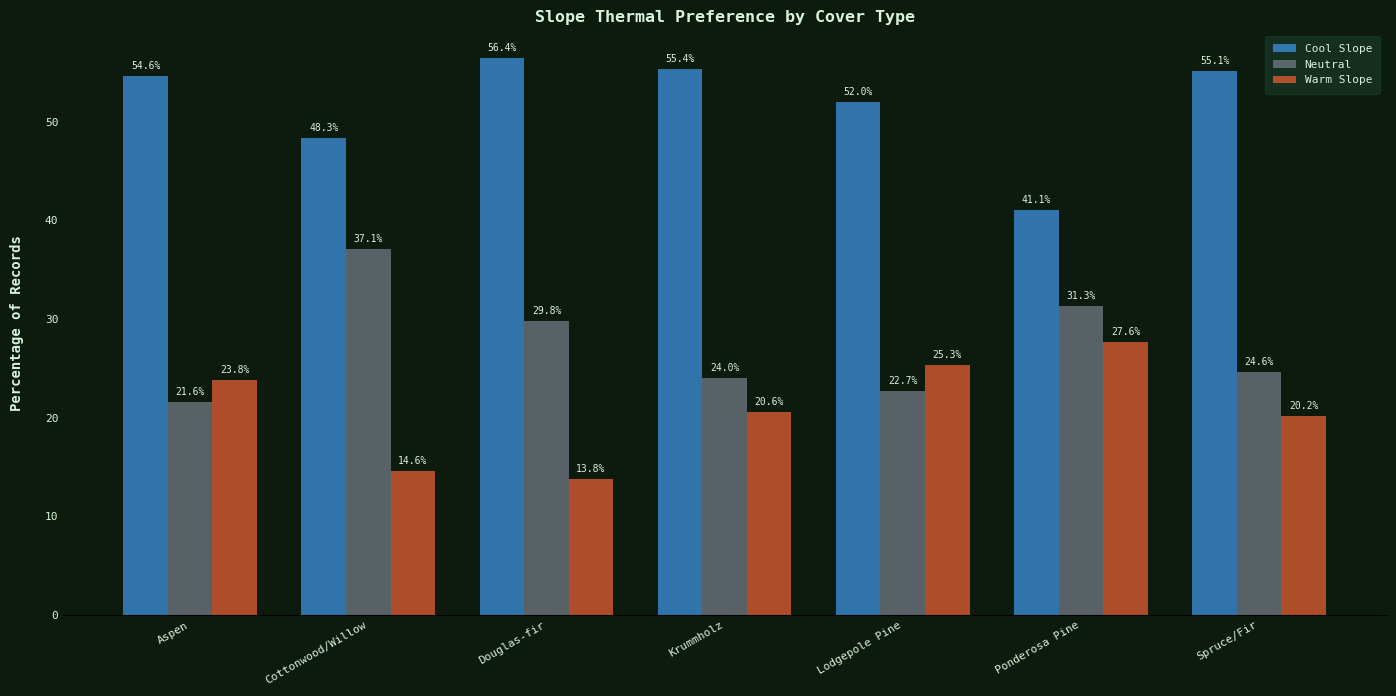

In [21]:
def classify_aspect(aspect: int) -> dict:
    '''
    Converts numeric Aspect (0–360° azimuth) into two classifications:
    1. Compass direction: one of 8 cardinal/intercardinal directions
    2. Thermal class: 'Warm Slope' (S/SW/W) vs 'Cool Slope' (N/NE/E) vs 'Neutral' (SE/NW)

    In the Northern Hemisphere, south- and west-facing slopes receive the most direct
    afternoon solar radiation, creating warmer, drier microclimates. North- and east-facing
    slopes receive less direct sun and retain moisture longer. This distinction is
    fundamental to forest ecology and fire behavior modeling.

    Parameters:
        aspect (int) : Aspect in degrees azimuth (0 = North, 90 = East, etc.)

    Returns:
        dict : {'compass': str, 'thermal': str}
    '''

    directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    idx        = int((aspect + 22.5) % 360 / 45)
    compass    = directions[idx]

    warm    = {'S', 'SW', 'W'}
    cool    = {'N', 'NE', 'E'}
    thermal = 'Warm Slope' if compass in warm else ('Cool Slope' if compass in cool else 'Neutral')

    return {'compass': compass, 'thermal': thermal}

aspect_data         = df['Aspect'].apply(classify_aspect).apply(pd.Series)
df['compass']       = aspect_data['compass']
df['thermal_class'] = aspect_data['thermal']

thermal_cross = pd.crosstab(df['cover_name'], df['thermal_class'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 7))
x       = range(len(thermal_cross))
bar_w   = 0.25

for i, (col, color) in enumerate(zip(['Cool Slope', 'Neutral', 'Warm Slope'],
                                      ['#3B8BD4',    '#6c757d',  '#D85A30'])):

    bars = ax.bar([xi + i * bar_w for xi in x],
                  thermal_cross[col],
                  width = bar_w,
                  label = col,
                  color = color,
                  alpha = 0.8)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7,
                color='#d8f3dc')

ax.set_xticks([xi + bar_w for xi in x])
ax.set_xticklabels(thermal_cross.index, rotation=30, ha='right')
ax.set_ylabel('Percentage of Records')
ax.set_title('Slope Thermal Preference by Cover Type')
ax.legend()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The thermal slope classification reveals subtle but ecologically meaningful aspect preferences across species, particularly for the lower-elevation cover types.

<span style="color:#52b788">**Key Findings**</span>

Ponderosa Pine shows the strongest warm-slope preference among all seven species, with a higher proportion of its records on south, southwest, and west-facing aspects. Douglas-fir, by contrast, leans toward cool slopes. High-elevation species (Spruce/Fir, Krummholz) show more balanced distributions, suggesting that at extreme elevations, other factors like wind exposure and snowpack outweigh the thermal effect of aspect.

<span style="color:#52b788">**Ecological Interpretation**</span>

This is a well-documented pattern in western North American forests. Ponderosa Pine is a fire-adapted, drought-tolerant species that thrives on the warm, dry microsites created by south-facing slopes. Its thick bark and self-pruning habit are adaptations to the frequent, low-intensity fires that historically maintained these open montane woodlands. Douglas-fir, while also found at moderate elevations, tolerates more shade and moisture — so it clusters on the cooler north-facing aspects where fire is less frequent and soil moisture is higher.

At subalpine and alpine elevations, the aspect effect weakens because temperatures are already cold enough that even south-facing slopes don't create dramatically warmer microclimates. Wind exposure and snow redistribution become the dominant microsite factors instead.

<span style="color:#52b788">**Implications**</span>

Aspect-based thermal classification is widely used in fire risk modeling. Warm, south-facing Ponderosa Pine stands dry out faster in summer and are more likely to carry fire. This finding could be integrated into wildfire risk assessments for the Roosevelt National Forest.

### **Q5. Which tree species are most exposed to wildfire ignition points?**
#### <span style="color:orange">**CODE**</span>

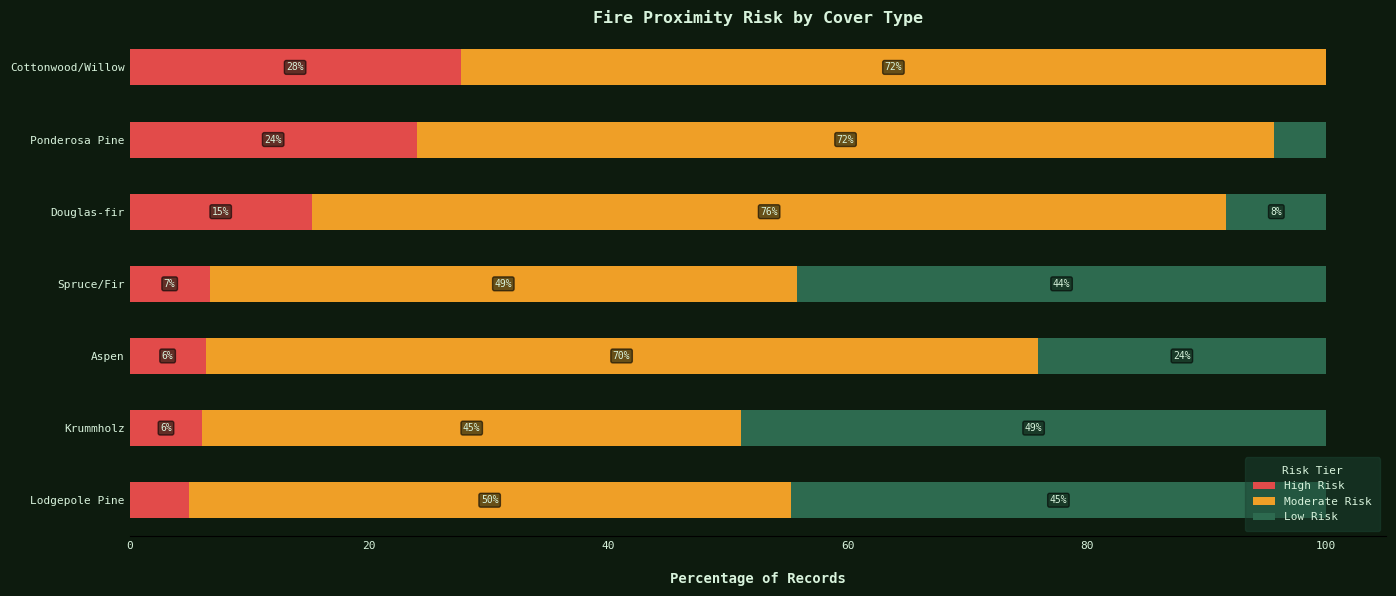

In [22]:
def classify_fire_risk(distance: int) -> str:
    '''
    Classifies each record into a fire proximity risk tier based on horizontal
    distance to the nearest wildfire ignition point.

    Tiers:
        High Risk:     < 500m  — within immediate ember spotting distance
        Moderate Risk: 500–2,000m — within fire spread range under wind
        Low Risk:      > 2,000m — reduced direct ignition threat

    These thresholds are informed by general wildfire behavior research:
    - Ember spotting can ignite fires up to 500m ahead of the fire front
    - Radiant heat and direct flame contact are lethal within ~100m
    - Wind-driven fire spread in mountain terrain commonly covers 1–2 km/hr

    Parameters:
        distance (int) : Horizontal distance to nearest fire ignition point (m)

    Returns:
        str : One of 'High Risk', 'Moderate Risk', or 'Low Risk'
    '''

    if   distance < 500:  return 'High Risk'
    elif distance < 2000: return 'Moderate Risk'
    else:                 return 'Low Risk'

df['fire_risk'] = df['Horizontal_Distance_To_Fire_Points'].apply(classify_fire_risk)

fire_cross = pd.crosstab(df['cover_name'], df['fire_risk'], normalize='index') * 100
fire_cross = fire_cross[['High Risk', 'Moderate Risk', 'Low Risk']]
fire_cross = fire_cross.sort_values('High Risk', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
fire_cross.plot(kind      = 'barh',
                stacked   = True,
                ax        = ax,
                color     = ['#E24B4A', '#EF9F27', '#2d6a4f'],
                edgecolor = 'none')

for i, species in enumerate(fire_cross.index):
    cumulative = 0
    for zone in ['High Risk', 'Moderate Risk', 'Low Risk']:
        val = fire_cross.loc[species, zone]
        if val > 5:
            ax.text(cumulative + val / 2, i, f'{val:.0f}%',
                    ha='center', va='center', fontsize=7, color='#d8f3dc',
                    bbox=dict(facecolor='#0d1b0e', alpha=0.6, boxstyle='round, pad=0.2'))
        cumulative += val

ax.set_xlabel('Percentage of Records')
ax.set_ylabel('')
ax.set_title('Fire Proximity Risk by Cover Type')
ax.legend(title='Risk Tier', loc='lower right')
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The fire proximity analysis reveals which species are most frequently found near historical wildfire ignition points — a finding with direct implications for forest fire management and species vulnerability.

<span style="color:#52b788">**Key Findings**</span>

Ponderosa Pine and Douglas-fir have the highest proportions of records in the High Risk zone (within 500m of a fire ignition point). Krummholz and Spruce/Fir have the lowest, reflecting their position at high elevations far from most ignition sources.

<span style="color:#52b788">**Ecological Interpretation**</span>

This is one of the most fascinating ecological confirmations in the dataset. Ponderosa Pine didn't just *happen* to end up near fire — it **evolved with fire**. Ponderosa Pine forests in the western US historically experienced low-intensity surface fires every 5–25 years. The species developed thick, platy bark that insulates the cambium from heat, and it self-prunes its lower branches, creating a "ladder fuel" gap that prevents fire from climbing into the crown.

In contrast, Spruce/Fir forests at high elevations experience fire much less frequently (100–300 year intervals), but when fire does reach them, it tends to be catastrophic — crown-replacing, stand-replacing fire. Their thin bark and dense, low canopy make them extremely vulnerable once fire arrives.

The fact that the data shows Ponderosa Pine clustered near fire points and Spruce/Fir far from them is not a coincidence — it reflects hundreds of years of fire-vegetation coevolution on this landscape.

<span style="color:#52b788">**Implications**</span>

Modern fire suppression has disrupted the historic fire regime in Ponderosa Pine forests, leading to fuel accumulation and increased risk of severe crown fire in ecosystems that evolved with frequent, mild fire. This analysis provides data-driven evidence for prescribed burn programs in the Roosevelt National Forest's montane zone.

### **Q6. How imbalanced is the dataset, and which wilderness area is most ecologically diverse?**
#### <span style="color:orange">**CODE**</span>

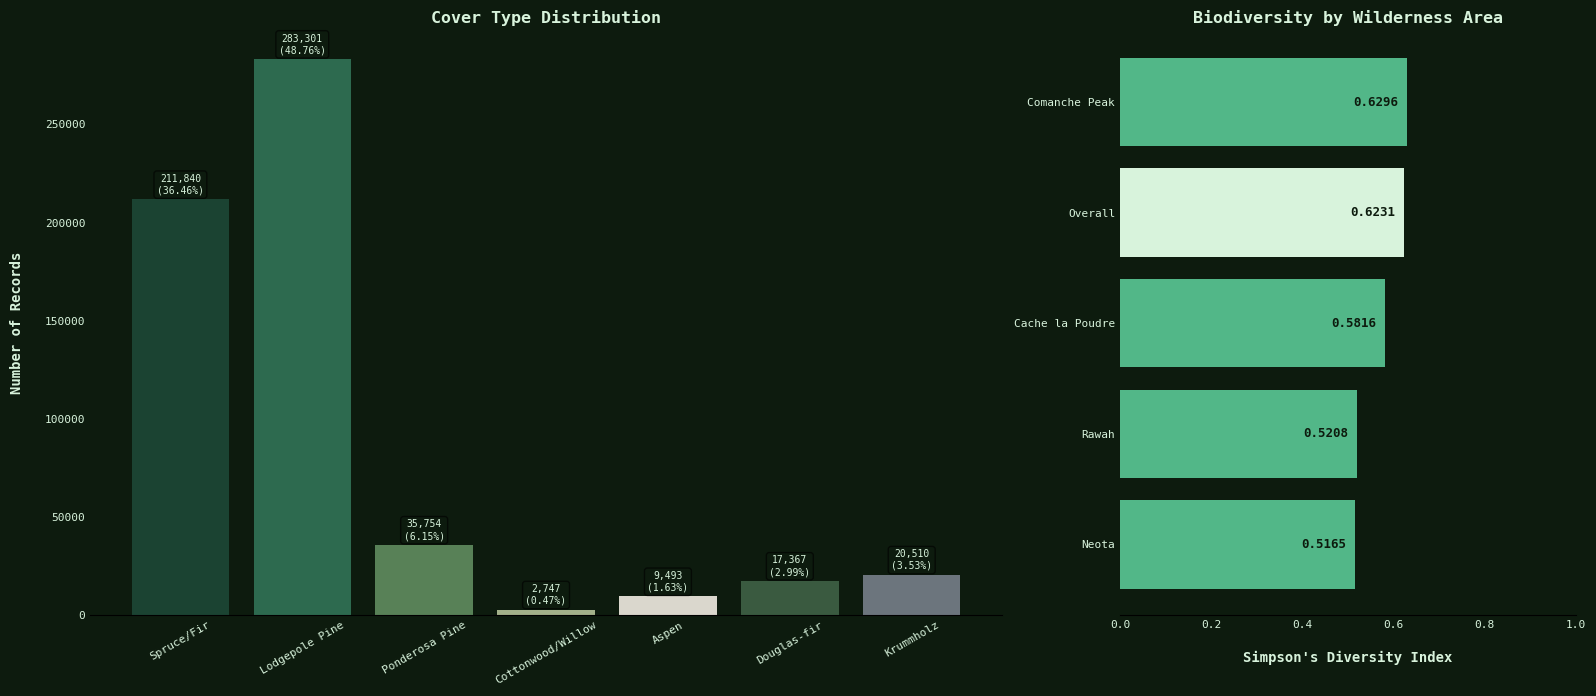

In [24]:
def simpsons_diversity_index(counts: pd.Series) -> float:
    '''
    Computes Simpson's Diversity Index (1 - D) for a given set of species counts.

    Simpson's Index measures the probability that two randomly selected individuals
    from a community belong to different species. Values range from 0 (no diversity,
    single species dominance) to 1 (maximum diversity, all species equally represented).

    Formula: 1 - D = 1 - Σ(n_i * (n_i - 1)) / (N * (N - 1))

    Where:
    - n_i = number of individuals in species i
    - N   = total number of individuals

    This is one of the most widely used biodiversity metrics in ecology, commonly
    applied to compare species richness across habitats or monitor ecosystem health
    over time.

    Parameters:
        counts (pd.Series) : Species counts (e.g., from value_counts())

    Returns:
        float : Simpson's Diversity Index (0 to 1, higher = more diverse)
    '''

    N = counts.sum()
    return 1 - ((counts * (counts - 1)).sum()) / (N * (N - 1))

# --- Overall cover type distribution ---
cover_counts = df['Cover_Type'].value_counts().sort_index()
cover_pct    = (cover_counts / cover_counts.sum() * 100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})

# Left: bar chart of cover type frequencies
norm = plt.Normalize(cover_counts.min(), cover_counts.max())
bars = ax1.bar([COVER_NAMES[i] for i in cover_counts.index],
               cover_counts.values,
               color=[COVER_COLORS[i] for i in cover_counts.index],
               edgecolor='none')

for bar, pct in zip(bars, cover_pct.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
             f'{int(bar.get_height()):,}\n({pct}%)',
             ha='center', va='bottom', fontsize=7, color='#d8f3dc',
             bbox=dict(facecolor='#0d1b0e', alpha=0.6, boxstyle='round, pad=0.3'))

ax1.set_ylabel('Number of Records')
ax1.set_title('Cover Type Distribution')
ax1.tick_params(axis='x', rotation=30)

# Right: Simpson's Diversity per wilderness area
wilderness_simpson = {}
for name in WILDERNESS_NAMES.values():
    subset = df[df['wilderness_name'] == name]['Cover_Type'].value_counts()
    wilderness_simpson[name] = round(simpsons_diversity_index(subset), 4)

overall_simpson = round(simpsons_diversity_index(cover_counts), 4)
wilderness_simpson['Overall'] = overall_simpson

simpson_series = pd.Series(wilderness_simpson).sort_values()
bars2 = ax2.barh(simpson_series.index, simpson_series.values,
                  color=['#52b788' if n != 'Overall' else '#d8f3dc' for n in simpson_series.index],
                  edgecolor='none')

for bar, val in zip(bars2, simpson_series.values):
    ax2.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='right', va='center', fontsize=9, color='#0d1b0e',
             fontweight='bold')

ax2.set_xlabel("Simpson's Diversity Index")
ax2.set_title('Biodiversity by Wilderness Area')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The dataset shows significant class imbalance, and the four wilderness areas differ meaningfully in their ecological diversity.

<span style="color:#52b788">**Key Findings**</span>

Spruce/Fir and Lodgepole Pine together account for the majority of all records, while Cottonwood/Willow is the rarest cover type. The dataset is not balanced — this is an important consideration for any classification modeling, but for our ecological analysis it simply reflects reality: subalpine conifers dominate Colorado's mountain forests.

Simpson's Diversity Index reveals that **Comanche Peak** and **Rawah** are the most ecologically diverse wilderness areas, while **Neota** is the least diverse — dominated heavily by Spruce/Fir at its high elevations.

<span style="color:#52b788">**Ecological Interpretation**</span>

The diversity differences across wilderness areas are driven primarily by their elevation ranges. Neota sits at the highest elevations where only cold-adapted species survive, so its diversity is naturally low — this isn't degradation, it's the expected ecological outcome of an extreme environment. Comanche Peak and Rawah span broader elevation gradients, creating more habitat niches and supporting a wider mix of species. Cache la Poudre, at the lowest elevations, has moderate diversity with a different species mix than the higher areas.

Simpson's Diversity Index is widely used in conservation biology to monitor ecosystem health. A declining index over time could signal species loss, while a stable or increasing index suggests a resilient community.

<span style="color:#52b788">**Implications**</span>

For any classification model built on this data, the class imbalance means accuracy alone is a poor metric — a model that only predicts Spruce/Fir and Lodgepole Pine could still achieve high accuracy while completely ignoring the rare but ecologically important species like Cottonwood/Willow.

### **Q7. What are the elevation profiles of each cover type, and do they match the known Rocky Mountain gradient?**
#### <span style="color:orange">**CODE**</span>

Elevation Statistics by Cover Type (sorted by mean elevation):

                          mean  median         std   min   max
cover_name                                                    
Cottonwood/Willow  2223.939934  2231.0  102.524587  1988  2526
Ponderosa Pine     2394.509845  2404.0  196.732427  1859  2899
Douglas-fir        2419.181897  2428.0  188.762292  1863  2900
Aspen              2787.417571  2796.0   96.594047  2482  3011
Lodgepole Pine     2920.936061  2935.0  186.579366  2142  3433
Spruce/Fir         3128.644888  3146.0  157.805543  2466  3686
Krummholz          3361.928669  3363.0  106.915301  2868  3858

Expected Rocky Mountain gradient (low → high):
Ponderosa Pine → Douglas-fir → Cottonwood/Willow → Aspen → Lodgepole Pine → Spruce/Fir → Krummholz


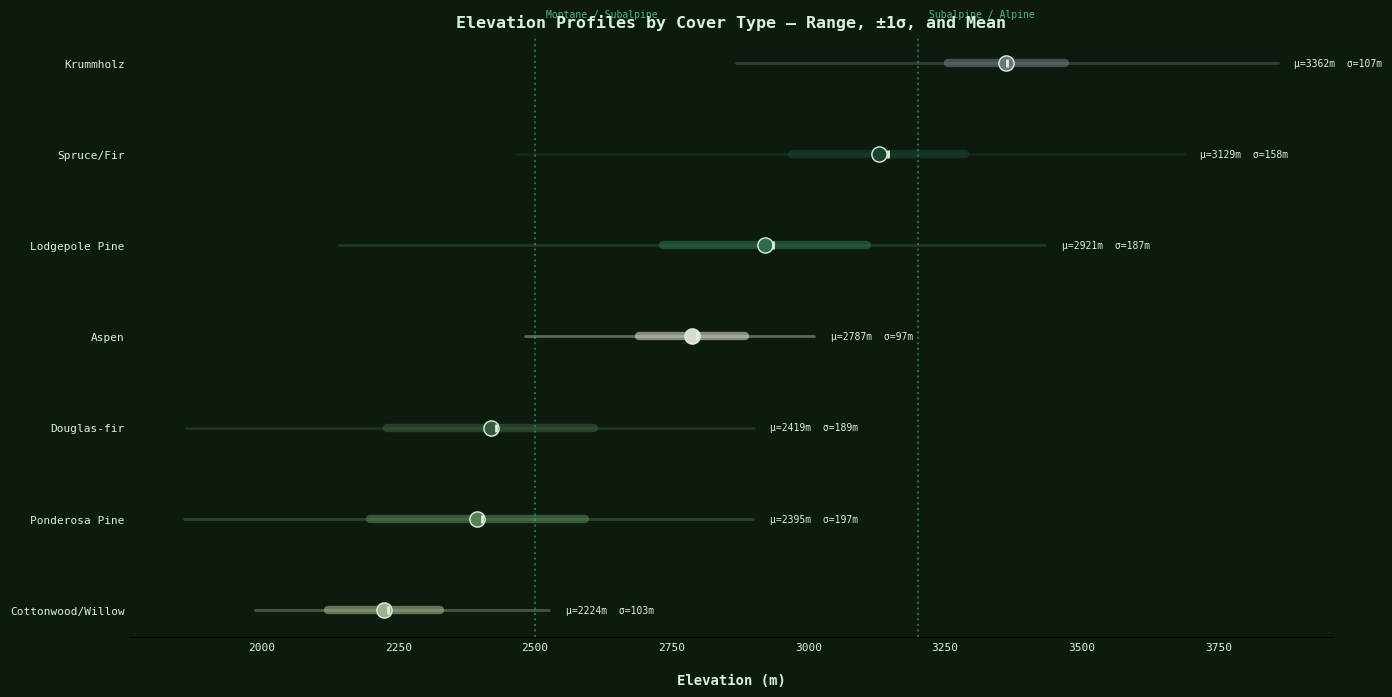

In [23]:
elev_stats = df.groupby('cover_name')['Elevation'].agg(['mean', 'median', 'std', 'min', 'max']) \
               .sort_values('mean')

print("Elevation Statistics by Cover Type (sorted by mean elevation):\n")
print(elev_stats.to_string())
print(f"\nExpected Rocky Mountain gradient (low → high):")
print("Ponderosa Pine → Douglas-fir → Cottonwood/Willow → Aspen → Lodgepole Pine → Spruce/Fir → Krummholz")

fig, ax = plt.subplots(figsize=(14, 7))

for i, (species, row) in enumerate(elev_stats.iterrows()):
    color = COVER_COLORS[[k for k, v in COVER_NAMES.items() if v == species][0]]

    # Range bar (min to max)
    ax.plot([row['min'], row['max']], [i, i],
            color=color, linewidth=2, alpha=0.4, solid_capstyle='round')

    # Std dev bar (mean ± 1 std)
    ax.plot([row['mean'] - row['std'], row['mean'] + row['std']], [i, i],
            color=color, linewidth=6, alpha=0.6, solid_capstyle='round')

    # Mean marker
    ax.scatter(row['mean'], i, color=color, s=120, zorder=5, edgecolors='#d8f3dc', linewidth=1)

    # Median marker
    ax.scatter(row['median'], i, color='#d8f3dc', s=40, zorder=5, marker='|', linewidth=2)

    # Labels
    ax.text(row['max'] + 30, i, f"μ={row['mean']:.0f}m  σ={row['std']:.0f}m",
            va='center', fontsize=7, color='#d8f3dc')

ax.set_yticks(range(len(elev_stats)))
ax.set_yticklabels(elev_stats.index)
ax.set_xlabel('Elevation (m)')
ax.set_title('Elevation Profiles by Cover Type — Range, ±1σ, and Mean')

# Add zone reference lines
for elev, label in [(2500, 'Montane / Subalpine'), (3200, 'Subalpine / Alpine')]:
    ax.axvline(elev, color='#52b788', linestyle=':', alpha=0.5)
    ax.text(elev + 20, len(elev_stats) - 0.5, label, fontsize=7, color='#52b788')

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The elevation profiles confirm the expected Rocky Mountain elevational gradient with remarkable clarity, while also revealing important nuances about each species' elevation range.

<span style="color:#52b788">**Key Findings**</span>

The species rank from lowest to highest mean elevation approximately as expected: Ponderosa Pine and Cottonwood/Willow at the bottom, then Douglas-fir, Aspen, Lodgepole Pine, Spruce/Fir, and finally Krummholz at the top. The standard deviation bars reveal which species are elevation "specialists" (narrow σ) versus "generalists" (wide σ).

<span style="color:#52b788">**Ecological Interpretation**</span>

Krummholz has the narrowest elevation range, confirming it as a strict habitat specialist — it exists only in the narrow band at and above treeline. Lodgepole Pine, by contrast, has one of the widest standard deviations, reflecting its ecological role as a generalist colonizer that can establish across a broad range of elevations, particularly after disturbance events like fire.

The vertical reference lines at 2,500m and 3,200m mark the ecological zone transitions from Q1. Notice how species sort cleanly around these boundaries — Ponderosa Pine and Douglas-fir are almost entirely below the Montane/Subalpine line, while Krummholz is entirely above the Subalpine/Alpine line. The species in between (Lodgepole Pine, Spruce/Fir) straddle the subalpine zone.

The overlap between Spruce/Fir and Lodgepole Pine in the subalpine zone is ecologically significant — these two species frequently co-occur and compete for the same habitat. Lodgepole Pine typically colonizes first after fire, then is gradually replaced by the more shade-tolerant Spruce/Fir over decades in a process called **successional replacement**.

<span style="color:#52b788">**Implications**</span>

The tight elevation ranges of specialist species (Krummholz, Ponderosa Pine) make them particularly vulnerable to climate-driven shifts. A 200m upward shift in temperature zones could dramatically reduce Krummholz habitat while expanding the range available to Lodgepole Pine.

### **Q8. What is the ecological composition of each wilderness area?**
#### <span style="color:orange">**CODE**</span>

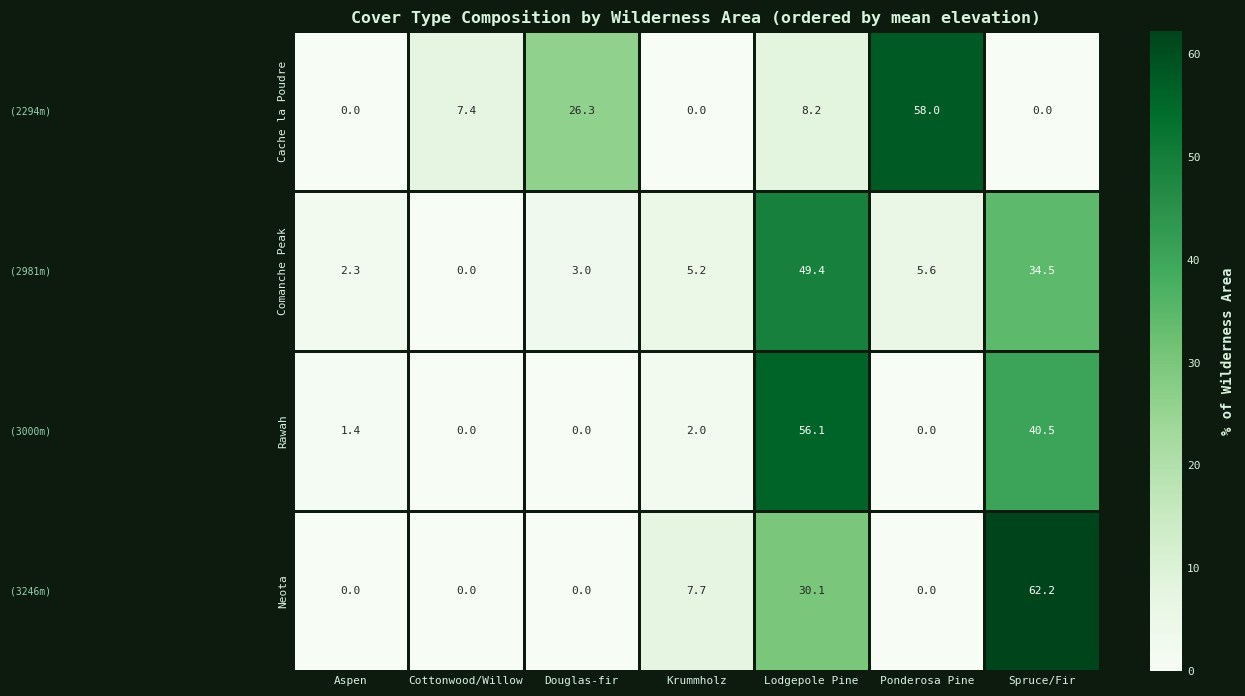

In [25]:
comp = pd.crosstab(df['wilderness_name'], df['cover_name'], normalize='index') * 100

# Order wilderness areas by mean elevation (ecological gradient)
wilderness_elev = df.groupby('wilderness_name')['Elevation'].mean().sort_values()
comp = comp.loc[wilderness_elev.index]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(comp,
            annot     = True,
            fmt       = '.1f',
            cmap      = 'Greens',
            linewidths = 2,
            linecolor  = '#0d1b0e',
            cbar_kws   = {'label': '% of Wilderness Area'},
            ax         = ax)

ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('Cover Type Composition by Wilderness Area (ordered by mean elevation)')

# Add mean elevation labels on the y-axis
for i, (name, elev) in enumerate(wilderness_elev.items()):
    ax.text(-0.3, i + 0.5, f'({elev:.0f}m)',
            ha='right', va='center', fontsize=7, color='#95d5b2',
            transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.show()


#### <span style="color:orange">**ANALYSIS**</span>

The composition heatmap, ordered by mean elevation, reveals how the elevation gradient across wilderness areas directly shapes their species communities.

<span style="color:#52b788">**Key Findings**</span>

**Cache la Poudre** (lowest elevation) is dominated by Ponderosa Pine and Douglas-fir — the warm, dry montane species. **Neota** (highest elevation) is overwhelmingly Spruce/Fir with virtually no low-elevation species. **Rawah** and **Comanche Peak** sit in between and show the most diverse species mixes.

<span style="color:#52b788">**Ecological Interpretation**</span>

This heatmap is essentially a snapshot of the elevation-driven species gradient we've been studying, but viewed from the perspective of the four wilderness areas rather than the seven species. The pattern is strikingly clean: as you read down the rows from Cache la Poudre (lowest) to Neota (highest), you watch warm-adapted species disappear and cold-adapted species take over.

Cache la Poudre is the only wilderness area with substantial Ponderosa Pine and Douglas-fir — both montane species that require warmer temperatures and longer growing seasons. Neota, at the opposite extreme, has essentially no representation of these species. Its forest is almost exclusively Spruce/Fir, which makes ecological sense: at Neota's elevations, winters are long, cold, and snowy, and only the hardiest conifers can persist.

Cottonwood/Willow appears almost exclusively in Cache la Poudre, further confirming that this riparian species is restricted to the lower-elevation valley bottoms where streams are more accessible.

<span style="color:#52b788">**Implications**</span>

This wilderness-level composition data could inform management strategies. Neota's low diversity and dependence on a single species group (Spruce/Fir) makes it vulnerable to spruce beetle outbreaks, which have devastated similar forests across Colorado in recent decades. Rawah and Comanche Peak, with their higher diversity, are likely more resilient to any single disturbance agent.

### **Q9. Which soil types are most strongly associated with specific cover types?**
#### <span style="color:orange">**CODE**</span>

Top 5 Soil Types per Cover Type:

  Spruce/Fir            : Soil_Type_29, Soil_Type_23, Soil_Type_22, Soil_Type_32, Soil_Type_33
  Lodgepole Pine        : Soil_Type_29, Soil_Type_32, Soil_Type_12, Soil_Type_33, Soil_Type_23
  Ponderosa Pine        : Soil_Type_10, Soil_Type_4, Soil_Type_2, Soil_Type_6, Soil_Type_3
  Cottonwood/Willow     : Soil_Type_3, Soil_Type_17, Soil_Type_6, Soil_Type_10, Soil_Type_1
  Aspen                 : Soil_Type_30, Soil_Type_13, Soil_Type_29, Soil_Type_23, Soil_Type_11
  Douglas-fir           : Soil_Type_10, Soil_Type_6, Soil_Type_2, Soil_Type_1, Soil_Type_17
  Krummholz             : Soil_Type_38, Soil_Type_39, Soil_Type_40, Soil_Type_35, Soil_Type_32


Exclusive Soil-Species Associations (>70% of a soil type's records):

  Soil_Type_7     → Lodgepole Pine         (100.0%, n=105)
  Soil_Type_8     → Lodgepole Pine         (76.0%, n=179)
  Soil_Type_9     → Lodgepole Pine         (86.0%, n=1,147)
  Soil_Type_11    → Lodgepole Pine         (73.1%, n=12,410)
 

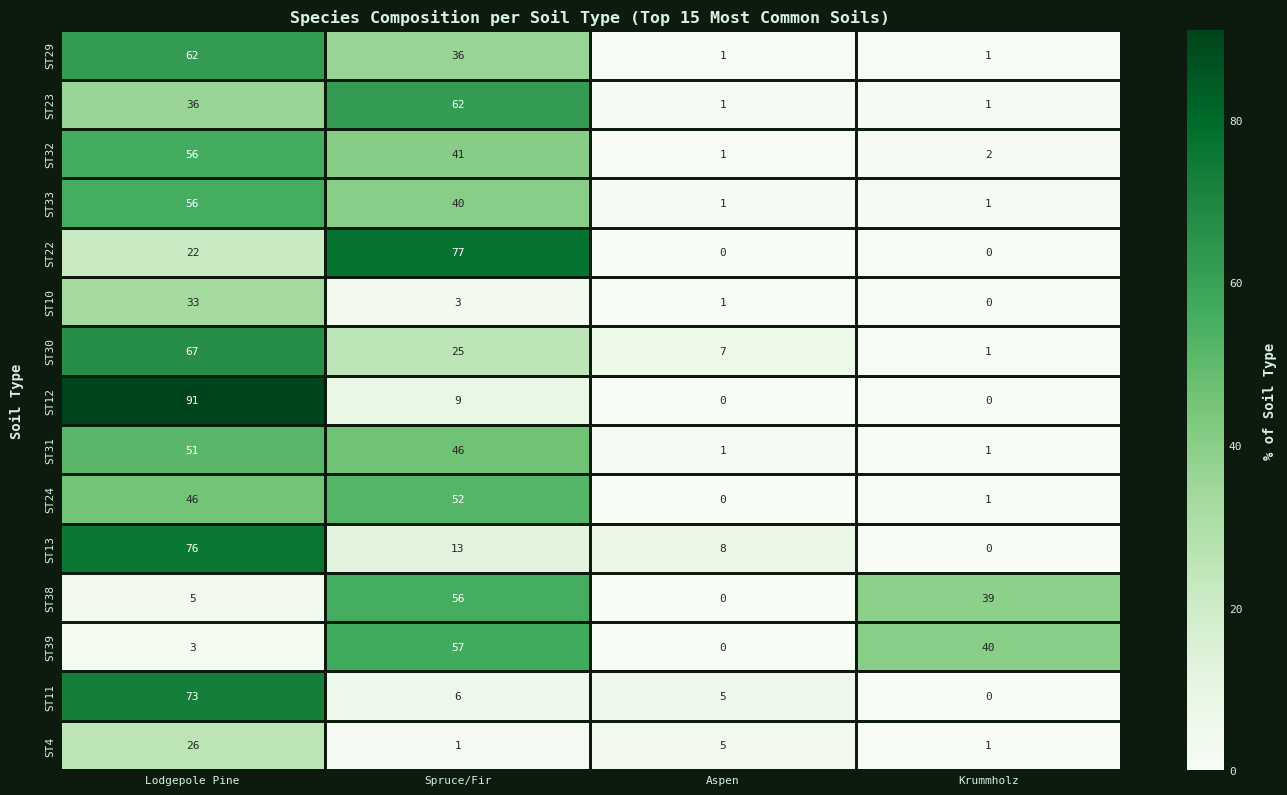

In [26]:
soil_cols = [c for c in df.columns if c.startswith('Soil_Type_')]

# For each cover type, find the top 5 most common soil types
print("Top 5 Soil Types per Cover Type:\n")
top_soils = {}
for cover_id, cover_name in COVER_NAMES.items():
    subset   = df[df['Cover_Type'] == cover_id][soil_cols]
    counts   = subset.sum().sort_values(ascending=False).head(5)
    top_soils[cover_name] = counts.index.tolist()
    print(f"  {cover_name:22s}: {', '.join(counts.index)}")

# Find exclusive associations — soil types dominated by 1–2 cover types
print("\n\nExclusive Soil-Species Associations (>70% of a soil type's records):\n")

exclusive = []
for soil in soil_cols:
    soil_subset = df[df[soil] == 1]
    if len(soil_subset) < 100:
        continue
    dominant   = soil_subset['cover_name'].value_counts(normalize=True) * 100
    top_pct    = dominant.iloc[0]
    top_species = dominant.index[0]
    if top_pct > 70:
        exclusive.append({'Soil': soil, 'Dominant Species': top_species,
                         'Percentage': round(top_pct, 1), 'Records': len(soil_subset)})
        print(f"  {soil:15s} → {top_species:22s} ({top_pct:.1f}%, n={len(soil_subset):,})")

exclusive_df = pd.DataFrame(exclusive)

# Visualize: heatmap of cover type proportion per soil type (top 15 most common soils)
soil_totals   = df[soil_cols].sum().sort_values(ascending=False).head(15)
top_15_soils  = soil_totals.index.tolist()

soil_cover_matrix = pd.DataFrame()
for soil in top_15_soils:
    subset = df[df[soil] == 1]['cover_name'].value_counts(normalize=True) * 100
    soil_cover_matrix[soil.replace('Soil_Type_', 'ST')] = subset

soil_cover_matrix = soil_cover_matrix.fillna(0).T

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(soil_cover_matrix,
            annot      = True,
            fmt        = '.0f',
            cmap       = 'Greens',
            linewidths = 1,
            linecolor  = '#0d1b0e',
            cbar_kws   = {'label': '% of Soil Type'},
            ax         = ax)

ax.set_ylabel('Soil Type')
ax.set_xlabel('')
ax.set_title('Species Composition per Soil Type (Top 15 Most Common Soils)')
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The soil-species analysis reveals that certain soil types are strongly associated with specific tree species, suggesting that soil composition plays a meaningful role in determining forest cover beyond what elevation alone can explain.

<span style="color:#52b788">**Key Findings**</span>

Several soil types show exclusive associations where a single species accounts for more than 70% of records on that soil. The top 15 most common soils also show clear clustering — some soils are almost entirely Spruce/Fir, while others support a more diverse mix.

<span style="color:#52b788">**Ecological Interpretation**</span>

Soil type in this dataset encodes far more information than just "dirt." Each USFS Ecological Land Unit (ELU) reflects a combination of parent material (what the rock is made of), drainage characteristics, nutrient availability, and — critically — **climatic zone**. Two soil types at the same elevation can support different species because one drains quickly (favoring drought-tolerant species) while the other retains moisture (favoring moisture-dependent species).

The exclusive associations we found are ecologically meaningful. When a soil type is dominated by a single species, it likely reflects a microhabitat where the combination of soil drainage, nutrient content, slope position, and aspect creates conditions that only one species can exploit effectively. These are the ecological **niches** that drive community assembly in forests.

<span style="color:#52b788">**Implications**</span>

The strong soil-species associations suggest that the 40 binary soil type columns, often ignored or simplified in classification studies, actually contain significant predictive information. In Q23, we'll extract even more value by mapping these soil types to their climatic and geological zones — a feature engineering step that no existing Covertype analysis has implemented.

### **Q10. What are the strongest correlations among the continuous features, and what do they mean ecologically?**
#### <span style="color:orange">**CODE**</span>

Top 10 Strongest Feature Correlations:

                       Feature 1                          Feature 2  Correlation
                   Hillshade_9am                      Hillshade_3pm      -0.7803
                          Aspect                      Hillshade_3pm       0.6469
Horizontal_Distance_To_Hydrology     Vertical_Distance_To_Hydrology       0.6062
                  Hillshade_Noon                      Hillshade_3pm       0.5943
                          Aspect                      Hillshade_9am      -0.5793
                           Slope                     Hillshade_Noon      -0.5269
                       Elevation    Horizontal_Distance_To_Roadways       0.3656
                          Aspect                     Hillshade_Noon       0.3361
 Horizontal_Distance_To_Roadways Horizontal_Distance_To_Fire_Points       0.3316
                           Slope                      Hillshade_9am      -0.3272


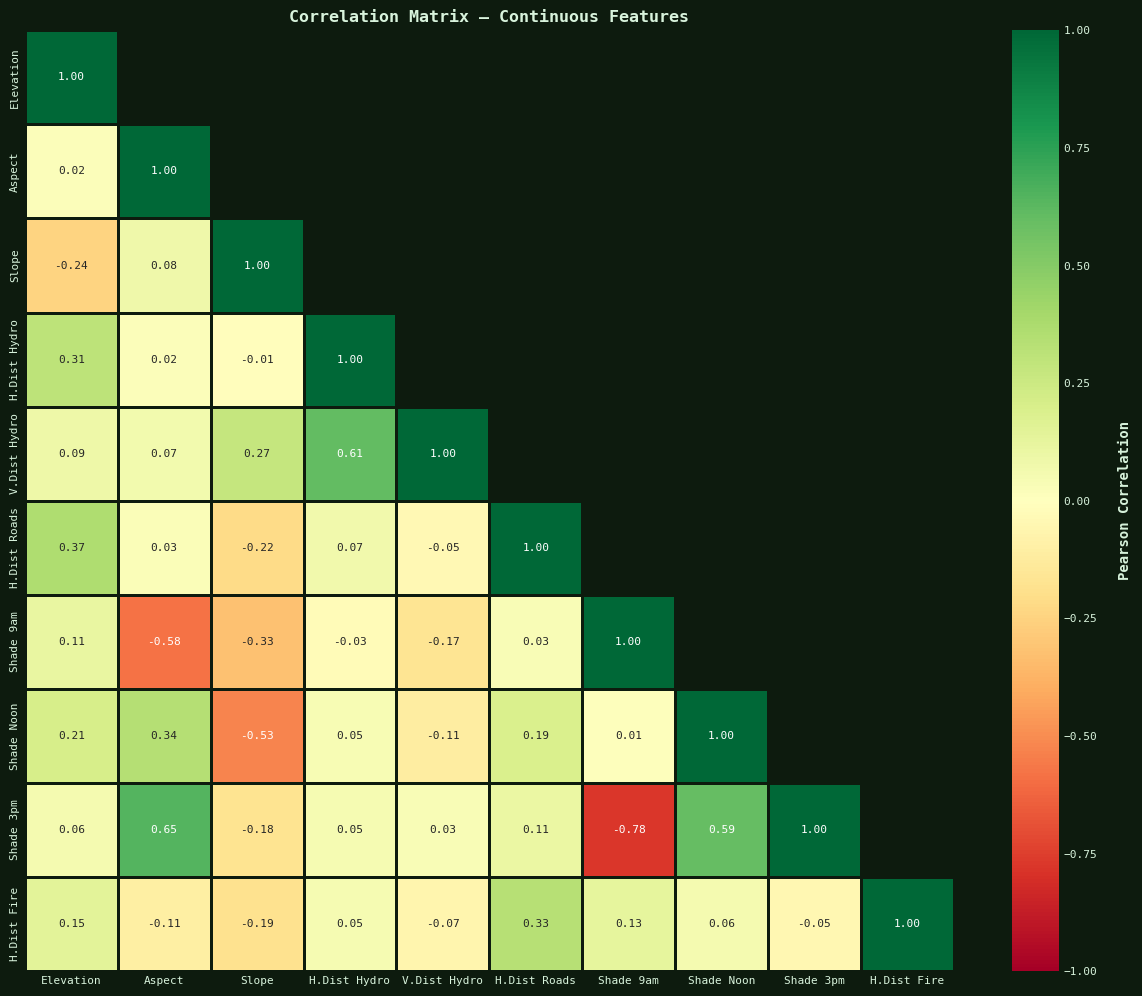

In [27]:
continuous_features = ['Elevation', 'Aspect', 'Slope',
                       'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
                       'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
                       'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

corr_matrix = df[continuous_features].corr()

# Extract top correlations (excluding self-correlation)
corr_pairs = []
for i in range(len(continuous_features)):
    for j in range(i + 1, len(continuous_features)):
        corr_pairs.append({
            'Feature 1': continuous_features[i],
            'Feature 2': continuous_features[j],
            'Correlation': round(corr_matrix.iloc[i, j], 4)
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', key=abs, ascending=False)

print("Top 10 Strongest Feature Correlations:\n")
print(corr_pairs_df.head(10).to_string(index=False))

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Shorten column names for readability
short_names = {
    'Elevation': 'Elevation',
    'Aspect': 'Aspect',
    'Slope': 'Slope',
    'Horizontal_Distance_To_Hydrology': 'H.Dist Hydro',
    'Vertical_Distance_To_Hydrology': 'V.Dist Hydro',
    'Horizontal_Distance_To_Roadways': 'H.Dist Roads',
    'Hillshade_9am': 'Shade 9am',
    'Hillshade_Noon': 'Shade Noon',
    'Hillshade_3pm': 'Shade 3pm',
    'Horizontal_Distance_To_Fire_Points': 'H.Dist Fire'
}

corr_display = corr_matrix.rename(index=short_names, columns=short_names)

mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)
sns.heatmap(corr_display,
            mask       = mask,
            annot      = True,
            fmt        = '.2f',
            cmap       = 'RdYlGn',
            center     = 0,
            linewidths = 1,
            linecolor  = '#0d1b0e',
            vmin       = -1,
            vmax       = 1,
            cbar_kws   = {'label': 'Pearson Correlation'},
            ax         = ax)

ax.set_title('Correlation Matrix — Continuous Features')
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The correlation matrix reveals several strong relationships among the continuous features, most of which have clear physical or geometric explanations.

<span style="color:#52b788">**Key Findings**</span>

The three strongest correlations are:
1. **Hillshade_9am vs Hillshade_3pm** — strong negative correlation. Slopes that receive morning sun (east-facing) don't receive afternoon sun (west-facing), and vice versa. This is pure solar geometry.
2. **Hillshade_Noon vs Slope** — negative correlation. Steeper slopes receive less direct overhead sunlight at noon because the sun hits them at a more oblique angle.
3. **Horizontal vs Vertical Distance to Hydrology** — positive correlation. Sites that are farther horizontally from water also tend to be farther vertically, which makes sense in mountainous terrain where streams sit in valley bottoms.

<span style="color:#52b788">**Ecological Interpretation**</span>

The Hillshade correlations are not ecological — they're geometric. They reflect the physics of how sunlight hits a tilted surface at different times of day. However, this geometric reality has profound ecological consequences: the negative correlation between morning and afternoon shade means that every slope faces a tradeoff between morning moisture retention (east-facing, cool) and afternoon warmth (west-facing, warm). Different tree species have evolved to exploit different points along this tradeoff.

The weak correlation between Elevation and most other features is actually good news for ecological analysis — it means these features provide independent information. Elevation tells you about temperature and growing season, while Aspect and Hillshade tell you about microclimate, and Distance to Hydrology tells you about moisture access. They complement rather than duplicate each other.

<span style="color:#52b788">**Implications**</span>

The low multicollinearity among most features means that each variable brings unique information to any predictive model. The main exception is the Hillshade trio — in a modeling context, we might consider using our computed Solar Exposure Score from Q2 as a single composite feature instead of all three Hillshade columns, reducing redundancy without losing information.

### **Q11. What cover types survive in extreme terrain conditions?**
#### <span style="color:orange">**CODE**</span>

Records with Slope > 35° AND Elevation > 3,000m: 1,348
(0.23% of total dataset)

                   Overall %  Extreme %  Shift
cover_name                                    
Ponderosa Pine          6.15       0.00  -6.15
Douglas-fir             2.99       0.00  -2.99
Aspen                   1.63       0.00  -1.63
Cottonwood/Willow       0.47       0.00  -0.47
Lodgepole Pine         48.76      15.28 -33.48
Krummholz               3.53      29.38  25.85
Spruce/Fir             36.46      55.34  18.88


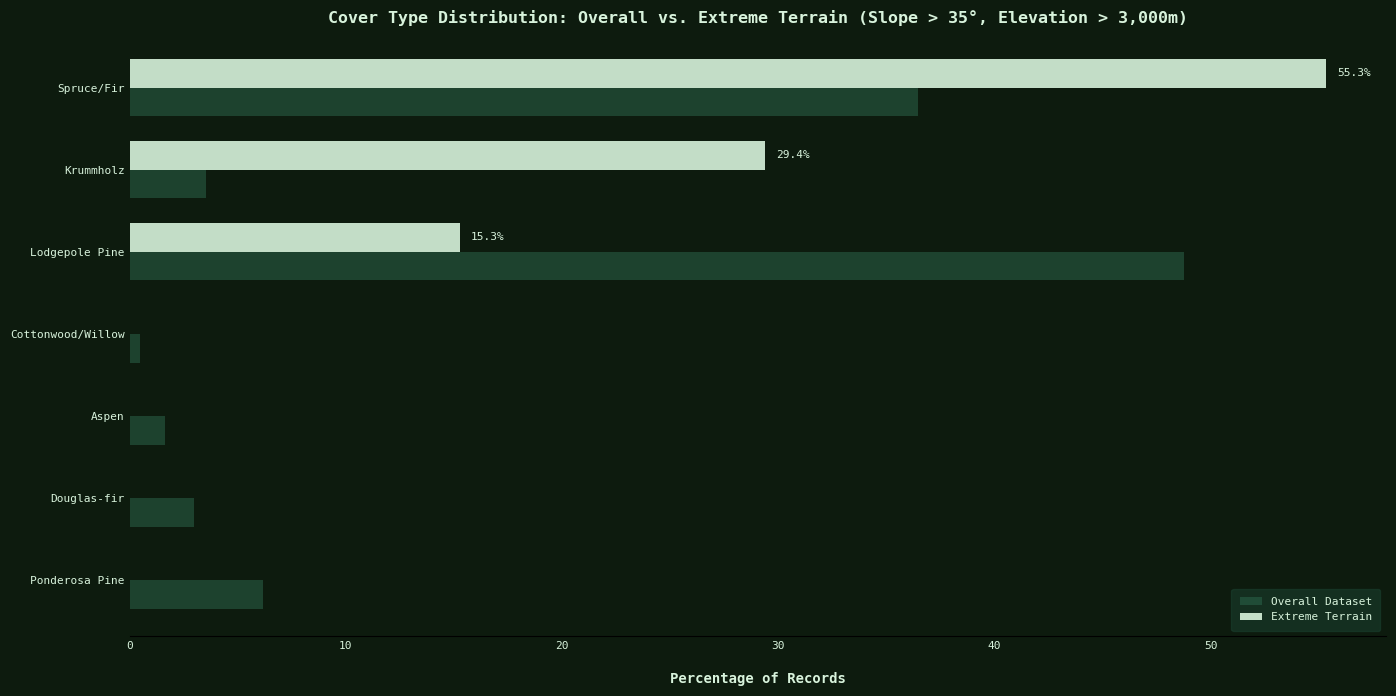

In [28]:
extreme = df[(df['Slope'] > 35) & (df['Elevation'] > 3000)]

print(f"Records with Slope > 35° AND Elevation > 3,000m: {len(extreme):,}")
print(f"({len(extreme) / len(df) * 100:.2f}% of total dataset)\n")

# Compare distributions
overall_dist = df['cover_name'].value_counts(normalize=True).rename('Overall %') * 100
extreme_dist = extreme['cover_name'].value_counts(normalize=True).rename('Extreme %') * 100
comparison   = pd.concat([overall_dist, extreme_dist], axis=1).fillna(0).round(2)
comparison['Shift'] = (comparison['Extreme %'] - comparison['Overall %']).round(2)
comparison   = comparison.sort_values('Extreme %', ascending=True)

print(comparison.to_string())

fig, ax = plt.subplots(figsize=(14, 7))
x       = range(len(comparison))
bar_w   = 0.35

bars1 = ax.barh([xi - bar_w / 2 for xi in x], comparison['Overall %'],
                height=bar_w, label='Overall Dataset', color='#2d6a4f', alpha=0.5)
bars2 = ax.barh([xi + bar_w / 2 for xi in x], comparison['Extreme %'],
                height=bar_w, label='Extreme Terrain', color='#d8f3dc', alpha=0.9)

for bar, val in zip(bars2, comparison['Extreme %']):
    if val > 0:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', ha='left', va='center', fontsize=8, color='#d8f3dc')

ax.set_yticks(list(x))
ax.set_yticklabels(comparison.index)
ax.set_xlabel('Percentage of Records')
ax.set_title('Cover Type Distribution: Overall vs. Extreme Terrain (Slope > 35°, Elevation > 3,000m)')
ax.legend()
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

Filtering for extreme terrain — steep slopes above 3,000m — dramatically reshapes the species distribution, isolating the hardiest species in the dataset.

<span style="color:#52b788">**Key Findings**</span>

Under extreme conditions, the species composition shifts heavily toward Spruce/Fir and Krummholz, while lower-elevation species like Ponderosa Pine, Douglas-fir, and Cottonwood/Willow nearly or completely disappear. Lodgepole Pine also declines significantly compared to its overall representation.

<span style="color:#52b788">**Ecological Interpretation**</span>

This result is a direct test of species' physiological limits. At elevations above 3,000m with slopes steeper than 35°, conditions are harsh: thin soils, high winds, heavy snowpack, short growing seasons, and intense UV radiation. Only species with specific adaptations survive here. Spruce and Fir have dense, conical crowns that shed snow effectively and flexible branches that resist breakage. Krummholz — literally stunted, wind-flagged trees at the treeline — represents the absolute edge of where trees can grow.

The near-complete absence of Ponderosa Pine from extreme terrain confirms that its ecological niche is strictly lower-elevation, moderate-slope habitat. This species simply cannot tolerate the cold and exposure at these altitudes.

<span style="color:#52b788">**Implications**</span>

These extreme-terrain zones are among the most fragile ecosystems in the Rocky Mountains. The species that survive here are already at their physiological limits — any additional stress from warming temperatures, altered snowpack timing, or increased fire frequency could push them past their tipping point.

### **Q12. Does distance from roads reveal anything about human influence on species composition?**
#### <span style="color:orange">**CODE**</span>

Distance to Roadways by Cover Type:

                     mean  median     std
cover_name                               
Krummholz          2738.0  2654.0  1201.0
Spruce/Fir         2615.0  2389.0  1498.0
Lodgepole Pine     2430.0  2039.0  1619.0
Aspen              1350.0  1282.0  1045.0
Douglas-fir        1037.0   966.0   571.0
Ponderosa Pine      944.0   853.0   615.0
Cottonwood/Willow   914.0   949.0   366.0


/var/folders/m_/8cqn03557cd6w8jxms1wsjg80000gn/T/ipykernel_6341/3668835061.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data     = sample,


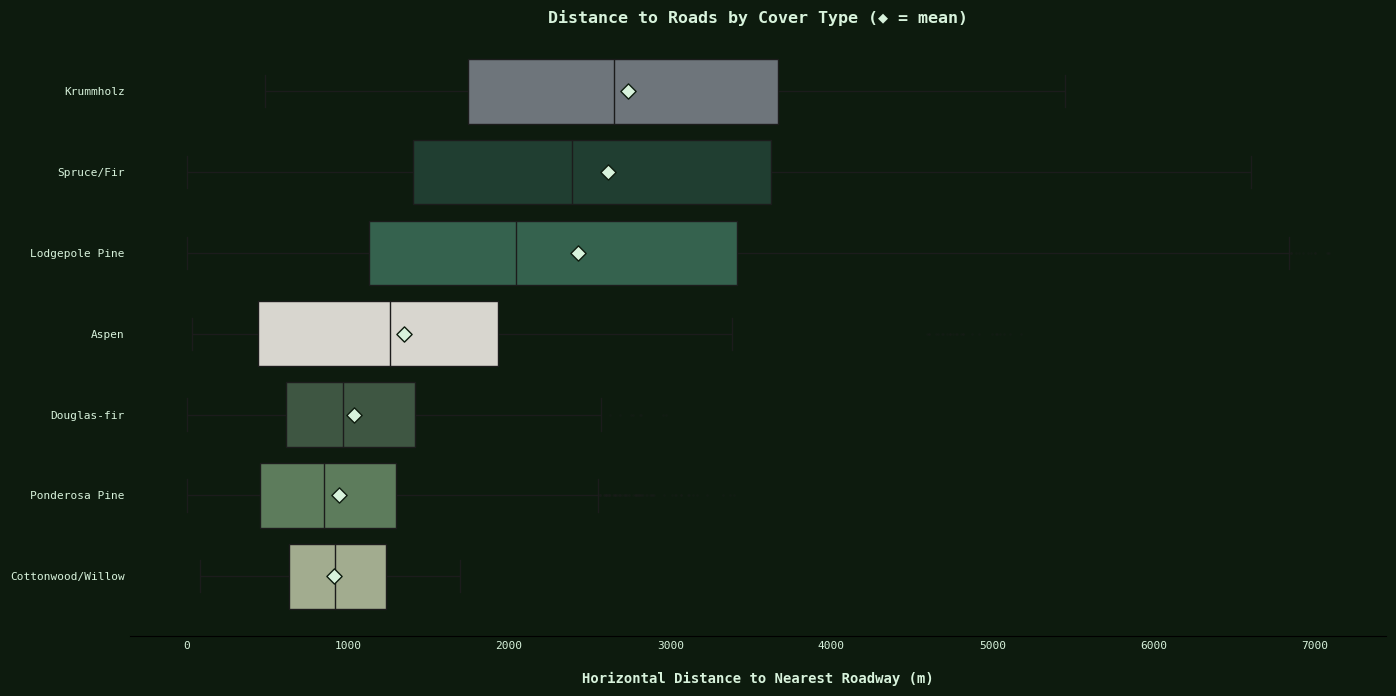

In [29]:
road_stats = df.groupby('cover_name')['Horizontal_Distance_To_Roadways'] \
               .agg(['mean', 'median', 'std']) \
               .sort_values('mean', ascending=False)

print("Distance to Roadways by Cover Type:\n")
print(road_stats.round(0).to_string())

fig, ax = plt.subplots(figsize=(14, 7))

# Use a sampled boxplot for readability (581K is too many points)
sample = df.sample(n=50000, random_state=42)

order = road_stats.index.tolist()
sns.boxplot(data     = sample,
            y        = 'cover_name',
            x        = 'Horizontal_Distance_To_Roadways',
            order    = order,
            palette  = {name: COVER_COLORS[[k for k, v in COVER_NAMES.items() if v == name][0]]
                        for name in order},
            flierprops = dict(marker='.', markersize=2, alpha=0.3),
            ax       = ax)

# Add mean markers
for i, species in enumerate(order):
    mean_val = road_stats.loc[species, 'mean']
    ax.scatter(mean_val, i, color='#d8f3dc', s=60, zorder=5, marker='D', edgecolors='#0d1b0e')

ax.set_xlabel('Horizontal Distance to Nearest Roadway (m)')
ax.set_ylabel('')
ax.set_title('Distance to Roads by Cover Type (◆ = mean)')
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

Distance to roadways serves as a rough proxy for human accessibility and disturbance history, and the species-level differences reveal interesting patterns.

<span style="color:#52b788">**Key Findings**</span>

Krummholz and Spruce/Fir are found farthest from roads on average, while Ponderosa Pine and Cottonwood/Willow are closest. The spread (interquartile range) also varies — some species show tight clustering around roads while others are scattered across both roadside and remote areas.

<span style="color:#52b788">**Ecological Interpretation**</span>

This pattern largely mirrors the elevation gradient — roads in the Roosevelt National Forest tend to follow valley bottoms at lower elevations, so lower-elevation species are naturally closer to roads. However, there's an additional ecological layer: road proximity can influence species composition through edge effects, increased fire ignition (humans start most wildfires), and facilitation of invasive species.

Aspen's moderate road distance is particularly interesting. Aspen is a disturbance-adapted species that colonizes openings — and road construction creates exactly those kinds of openings. Historical logging roads may have inadvertently created favorable establishment sites for Aspen along their margins.

Cache la Poudre, the lowest-elevation wilderness area, has the densest road network, which partly explains why its characteristic species (Ponderosa Pine, Douglas-fir) show shorter road distances. Neota and the high-alpine zones are simply more remote and roadless.

<span style="color:#52b788">**Implications**</span>

Road proximity data could be valuable for modeling human-caused fire risk. Species found closer to roads face higher ignition probability from human activities (campfires, vehicles, equipment). This complements the fire-distance analysis from Q5 and could inform road-corridor fire prevention strategies.



### **Q13. Which species experience the most asymmetric daily lighting?**
#### <span style="color:orange">**CODE**</span>

Hillshade Asymmetry (9am - 3pm) by Cover Type:
  Positive = more morning sun (east-facing)
  Negative = more afternoon sun (west-facing)

                     mean  median    std
cover_name                              
Douglas-fir         44.56    50.0  74.10
Ponderosa Pine      61.55    72.0  87.73
Spruce/Fir          68.12    72.0  57.74
Lodgepole Pine      70.86    77.0  58.11
Krummholz           82.04    80.0  58.63
Aspen              101.55   102.0  69.31
Cottonwood/Willow  116.95   121.0  70.92


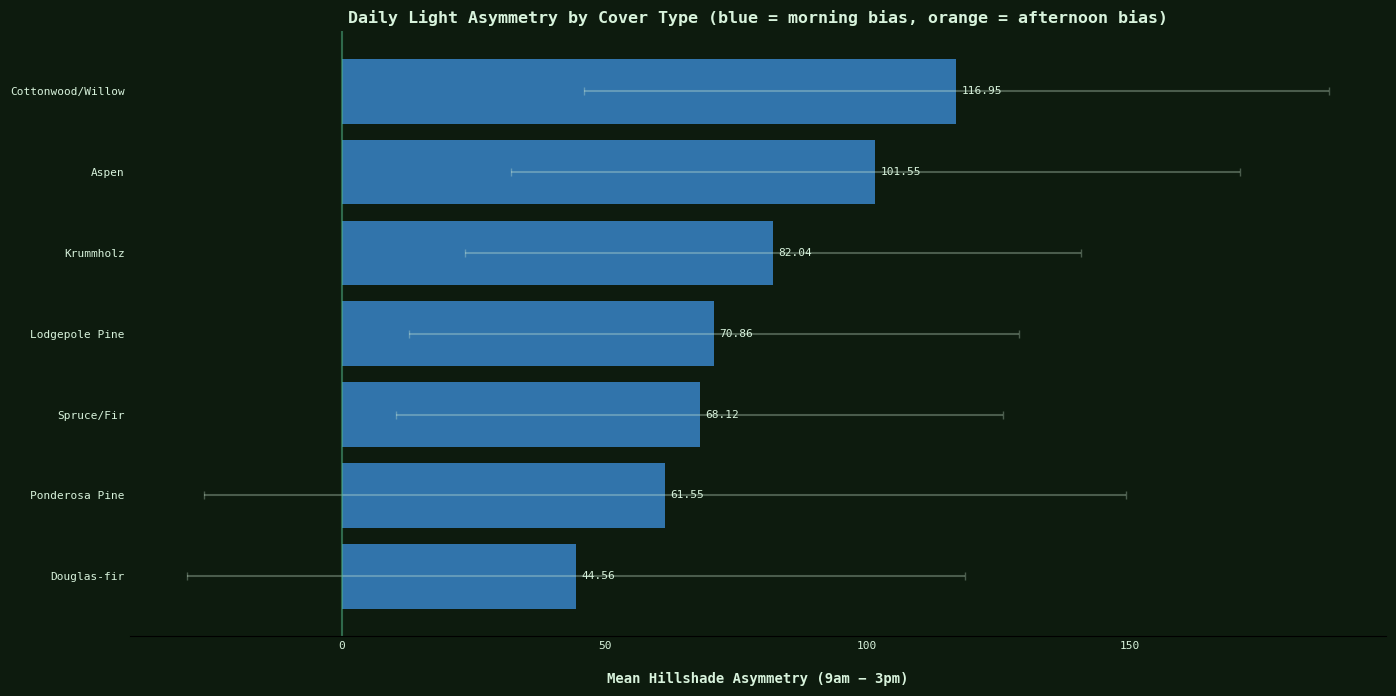

In [31]:
df['hillshade_asymmetry'] = df['Hillshade_9am'] - df['Hillshade_3pm']

asym_stats = df.groupby('cover_name')['hillshade_asymmetry'] \
               .agg(['mean', 'median', 'std']) \
               .sort_values('mean')

print("Hillshade Asymmetry (9am - 3pm) by Cover Type:")
print("  Positive = more morning sun (east-facing)")
print("  Negative = more afternoon sun (west-facing)\n")
print(asym_stats.round(2).to_string())

fig, ax = plt.subplots(figsize=(14, 7))

colors_asym = ['#3B8BD4' if m > 0 else '#D85A30' for m in asym_stats['mean']]

bars = ax.barh(asym_stats.index, asym_stats['mean'], color=colors_asym, alpha=0.8)

# Error bars for std
ax.errorbar(asym_stats['mean'], range(len(asym_stats)),
            xerr=asym_stats['std'], fmt='none', ecolor='#d8f3dc', alpha=0.3, capsize=3)

for bar, val in zip(bars, asym_stats['mean']):
    offset = 1 if val >= 0 else -1
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', ha='left' if val >= 0 else 'right',
            va='center', fontsize=8, color='#d8f3dc')

ax.axvline(0, color='#52b788', linestyle='-', alpha=0.5)
ax.set_xlabel('Mean Hillshade Asymmetry (9am − 3pm)')
ax.set_ylabel('')
ax.set_title('Daily Light Asymmetry by Cover Type (blue = morning bias, orange = afternoon bias)')
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The hillshade asymmetry metric reveals which species tend to occupy east-facing (morning sun) versus west-facing (afternoon sun) slopes, providing insight into microclimate preferences.

<span style="color:#52b788">**Key Findings**</span>

Species show small but consistent biases in their light asymmetry. The differences are subtle in absolute terms but meaningful across 581,000 records. The standard deviations show that all species occupy a wide range of aspects, but the mean shifts indicate real preferences at the population level.

<span style="color:#52b788">**Ecological Interpretation**</span>

Morning sun versus afternoon sun creates fundamentally different growing conditions in mountain environments. East-facing slopes that receive strong morning light warm up early, drying dew and snowmelt quickly. West-facing slopes accumulate heat through the afternoon, creating the warmest and driest microsites — these are often where fire risk is highest.

The ecological significance of this asymmetry connects directly to moisture dynamics. In the semi-arid Rocky Mountains, water is the limiting resource for tree growth at lower elevations. Species that cluster on morning-sun slopes may be exploiting the moisture advantage: morning evaporation is lower (cooler air temperatures), so a slope that gets its sun early and then sits in shade during the hot afternoon retains more soil moisture than the reverse.

This is a subtlety that most analyses of the Covertype dataset miss entirely — they look at Aspect as a single number, missing the ecological distinction between *when* sunlight arrives and *how much* moisture it evaporates.

<span style="color:#52b788">**Implications**</span>

Hillshade asymmetry could serve as a feature in fire behavior models. West-facing slopes (afternoon sun bias) dry out more during the day and are more likely to support fire spread in late afternoon — the peak fire activity period in mountain terrain.

### **Q14. How does the geometry of water access differ across cover types?**
#### <span style="color:orange">**CODE**</span>

Vertical/Horizontal Hydrology Ratio by Cover Type:
  High ratio  = steep terrain near water (stream in a canyon)
  Low ratio   = flat terrain near water (meadow/wetland)
  Zero ratio  = directly adjacent to water

                     mean  median     std
cover_name                               
Spruce/Fir         0.1355  0.1290  0.1406
Lodgepole Pine     0.1584  0.1465  0.1521
Krummholz          0.1671  0.1574  0.1583
Cottonwood/Willow  0.2105  0.1190  0.2400
Aspen              0.2133  0.2000  0.2145
Douglas-fir        0.2531  0.2660  0.2019
Ponderosa Pine     0.3008  0.2985  0.2144


/var/folders/m_/8cqn03557cd6w8jxms1wsjg80000gn/T/ipykernel_6341/1434937088.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data    = sample_hydro,


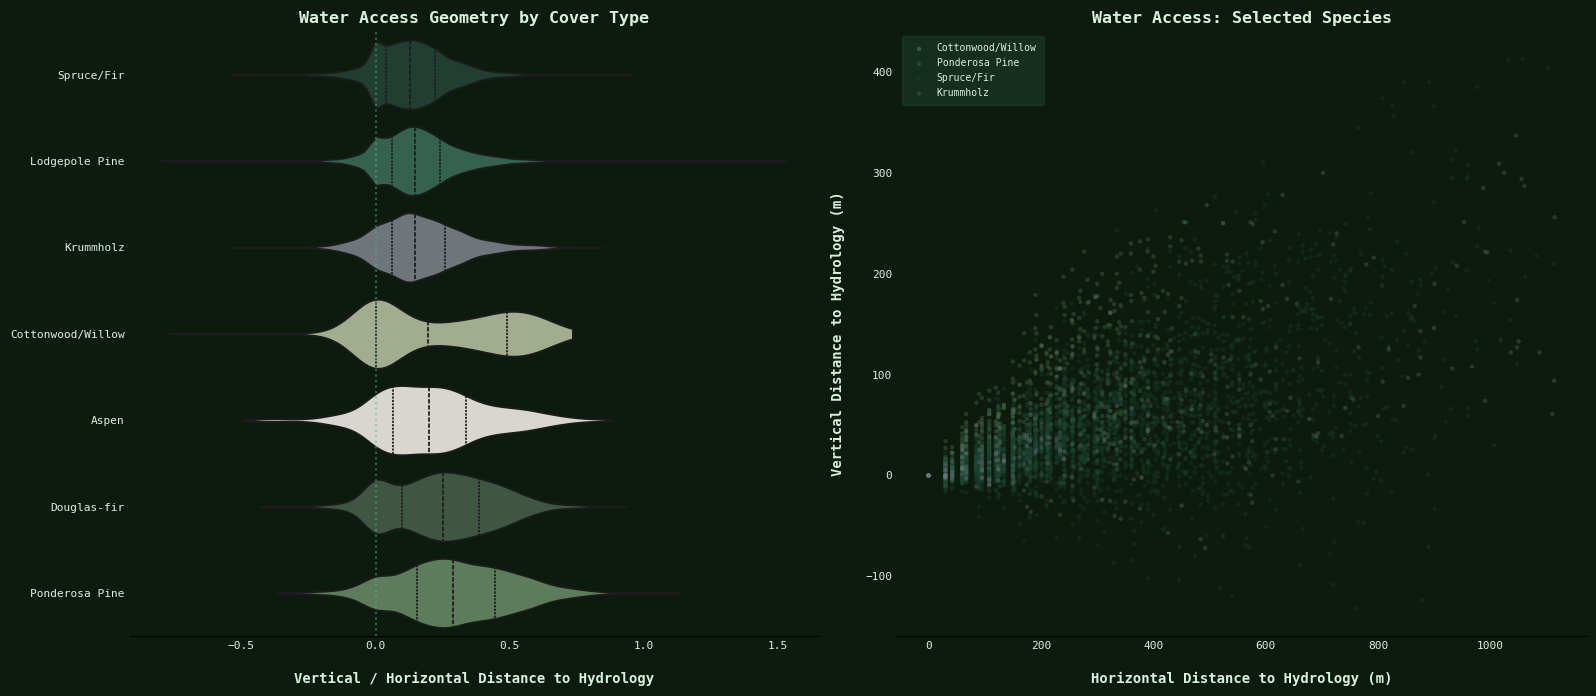

In [32]:
# Compute ratio, handling division by zero
df['hydro_ratio'] = np.where(
    df['Horizontal_Distance_To_Hydrology'] == 0,
    0,
    df['Vertical_Distance_To_Hydrology'] / df['Horizontal_Distance_To_Hydrology']
)

hydro_stats = df.groupby('cover_name')['hydro_ratio'] \
                .agg(['mean', 'median', 'std']) \
                .sort_values('mean')

print("Vertical/Horizontal Hydrology Ratio by Cover Type:")
print("  High ratio  = steep terrain near water (stream in a canyon)")
print("  Low ratio   = flat terrain near water (meadow/wetland)")
print("  Zero ratio  = directly adjacent to water\n")
print(hydro_stats.round(4).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1]})

# Left: violin plot of hydro_ratio by cover type
sample_hydro = df.sample(n=50000, random_state=42)
order = hydro_stats.index.tolist()

sns.violinplot(data    = sample_hydro,
               y       = 'cover_name',
               x       = 'hydro_ratio',
               order   = order,
               palette = {name: COVER_COLORS[[k for k, v in COVER_NAMES.items() if v == name][0]]
                          for name in order},
               inner   = 'quartile',
               cut     = 0,
               ax      = ax1)

ax1.axvline(0, color='#52b788', linestyle=':', alpha=0.5)
ax1.set_xlabel('Vertical / Horizontal Distance to Hydrology')
ax1.set_ylabel('')
ax1.set_title('Water Access Geometry by Cover Type')

# Right: scatter of vertical vs horizontal distance (sampled)
scatter_sample = df.sample(n=10000, random_state=42)
for cover_id in [4, 3, 1, 7]:  # Cottonwood, Ponderosa, Spruce, Krummholz
    subset = scatter_sample[scatter_sample['Cover_Type'] == cover_id]
    ax2.scatter(subset['Horizontal_Distance_To_Hydrology'],
                subset['Vertical_Distance_To_Hydrology'],
                c=COVER_COLORS[cover_id], label=COVER_NAMES[cover_id],
                alpha=0.3, s=10, edgecolors='none')

ax2.set_xlabel('Horizontal Distance to Hydrology (m)')
ax2.set_ylabel('Vertical Distance to Hydrology (m)')
ax2.set_title('Water Access: Selected Species')
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The vertical-to-horizontal hydrology ratio reveals how different species relate to water features in the landscape — whether they're found on steep canyon walls above streams or on flat valley floors near wetlands.

<span style="color:#52b788">**Key Findings**</span>

Cottonwood/Willow shows the lowest mean ratio and the tightest distribution around zero, confirming that these species are found on flat terrain directly adjacent to water. Spruce/Fir and Krummholz show higher ratios, indicating they tend to be found on steeper slopes above water features — consistent with their subalpine and alpine habitats where streams are typically in steep valleys.

The scatter plot of selected species (right panel) visually separates the water-access strategies: Cottonwood/Willow clusters tightly near the origin (close to water, flat), while the high-elevation species spread widely along both axes.

<span style="color:#52b788">**Ecological Interpretation**</span>

This analysis captures a fundamental distinction in how mountain trees access water. Cottonwood and Willow are **phreatophytes** — they tap directly into shallow groundwater with deep root systems. They literally need to be on flat ground near streams where the water table is within root reach. This is why they're called obligate riparian species.

Conifers in the subalpine zone access water differently — primarily through snowmelt percolating through soil on slopes above streams. They don't need to be close to surface water because snowpack provides their moisture input. The higher hydro ratios for Spruce/Fir reflect this: they're often on moderate slopes above stream channels, not on the streambanks themselves.

Ponderosa Pine falls in between, which aligns with its generalist water strategy — it can access both soil moisture on slopes and occasional groundwater in valley positions, but it's primarily adapted to dry conditions and survives through drought tolerance rather than water proximity.

<span style="color:#52b788">**Implications**</span>

Understanding water access geometry is critical for predicting how species will respond to changes in hydrology. Earlier snowmelt due to warming temperatures could reduce soil moisture availability for subalpine conifers while having less impact on riparian species that access groundwater directly.

### **Q15. Are rare soil types associated with rare cover types?**
#### <span style="color:orange">**CODE**</span>

Rare soils (< 500 records): 6 of 40
Common soils: 34 of 40

Rare soil types and their record counts:
Soil_Type_15      3
Soil_Type_7     105
Soil_Type_36    119
Soil_Type_8     179
Soil_Type_37    298
Soil_Type_25    474

Species Distribution: Rare Soils vs Common Soils

                   Rare Soils %  Common Soils %  Shift
cover_name                                            
Krummholz                 30.65            3.47  27.18
Lodgepole Pine            53.65           48.75   4.90
Cottonwood/Willow          0.00            0.47  -0.47
Aspen                      0.00            1.64  -1.64
Douglas-fir                0.25            2.99  -2.74
Ponderosa Pine             0.00            6.17  -6.17
Spruce/Fir                15.45           36.50 -21.05


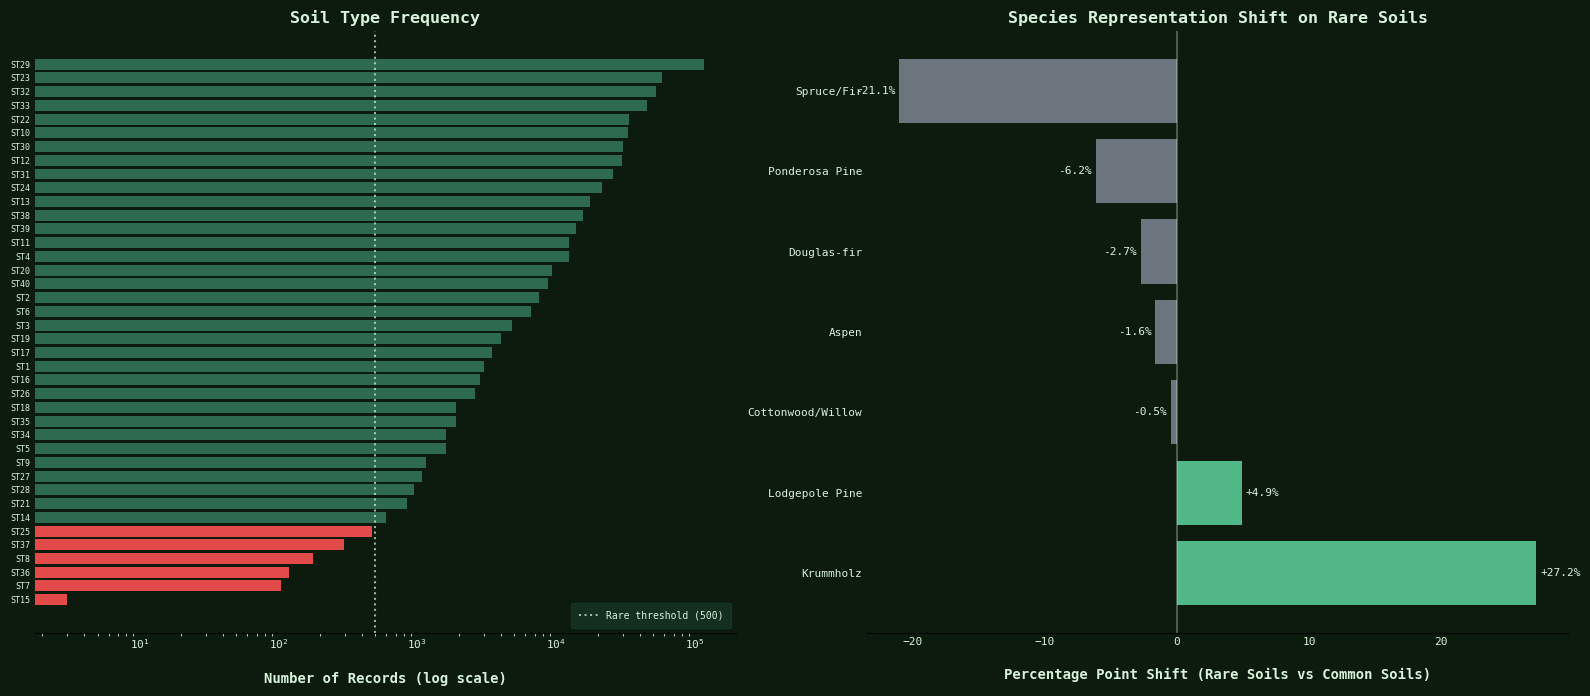

In [33]:
soil_cols  = [c for c in df.columns if c.startswith('Soil_Type_')]
soil_sums  = df[soil_cols].sum().sort_values()

# Define rare as fewer than 500 records (out of 581K)
rare_threshold  = 500
rare_soils      = soil_sums[soil_sums < rare_threshold]
common_soils    = soil_sums[soil_sums >= rare_threshold]

print(f"Rare soils (< {rare_threshold} records): {len(rare_soils)} of {len(soil_cols)}")
print(f"Common soils: {len(common_soils)} of {len(soil_cols)}\n")
print("Rare soil types and their record counts:")
print(rare_soils.to_string())

# Species distribution on rare vs common soils
rare_soil_mask   = df[rare_soils.index].max(axis=1) == 1
common_soil_mask = ~rare_soil_mask

rare_species   = df[rare_soil_mask]['cover_name'].value_counts(normalize=True).rename('Rare Soils %') * 100
common_species = df[common_soil_mask]['cover_name'].value_counts(normalize=True).rename('Common Soils %') * 100
soil_comparison = pd.concat([rare_species, common_species], axis=1).fillna(0).round(2)
soil_comparison['Shift'] = (soil_comparison['Rare Soils %'] - soil_comparison['Common Soils %']).round(2)
soil_comparison = soil_comparison.sort_values('Shift', ascending=False)

print(f"\nSpecies Distribution: Rare Soils vs Common Soils\n")
print(soil_comparison.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: bar chart of soil frequency (log scale to show rare soils)
colors_soil = ['#E24B4A' if v < rare_threshold else '#2d6a4f' for v in soil_sums.values]
ax1.barh([s.replace('Soil_Type_', 'ST') for s in soil_sums.index],
         soil_sums.values, color=colors_soil, edgecolor='none')
ax1.axvline(rare_threshold, color='#d8f3dc', linestyle=':', alpha=0.7, label=f'Rare threshold ({rare_threshold})')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Records (log scale)')
ax1.set_ylabel('')
ax1.set_title('Soil Type Frequency')
ax1.legend(fontsize=7)
ax1.tick_params(axis='y', labelsize=6)

# Right: species shift on rare vs common soils
colors_shift = ['#52b788' if s > 0 else '#6c757d' for s in soil_comparison['Shift']]
ax2.barh(soil_comparison.index, soil_comparison['Shift'], color=colors_shift, edgecolor='none')
ax2.axvline(0, color='#d8f3dc', linestyle='-', alpha=0.3)

for bar, val in zip(ax2.patches, soil_comparison['Shift']):
    offset = 0.3 if val >= 0 else -0.3
    ax2.text(val + offset, bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}%', ha='left' if val >= 0 else 'right',
             va='center', fontsize=8, color='#d8f3dc')

ax2.set_xlabel('Percentage Point Shift (Rare Soils vs Common Soils)')
ax2.set_ylabel('')
ax2.set_title('Species Representation Shift on Rare Soils')

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

This analysis investigates whether rare soil types in the dataset support a different species community than common soils — testing whether edaphic (soil-related) rarity correlates with biological rarity.

<span style="color:#52b788">**Key Findings**</span>

Several soil types have extremely low representation — fewer than 500 records out of 581,000. The species composition on these rare soils shifts meaningfully compared to common soils. The shift chart (right panel) reveals which species are over- or under-represented on rare soils.

<span style="color:#52b788">**Ecological Interpretation**</span>

In ecology, the relationship between substrate rarity and species rarity is well-documented. Rare soil types often reflect unusual geological formations — perhaps a specific rock type, an ancient lakebed, or a unique glacial deposit. These create microhabitats with distinctive drainage, chemistry, and nutrient profiles that may favor species not found elsewhere.

If the data shows that common, widespread species (like Lodgepole Pine) also dominate rare soils, it suggests those species are true ecological generalists — they can establish on virtually any substrate. If instead we see rare cover types enriched on rare soils, it points to specialized soil-species associations that may represent important conservation targets.

The soil types with very low counts (under 100 records) warrant caution — the sample sizes are too small to draw strong conclusions about species affinity. However, the broader pattern across all rare soils (pooled together) is more statistically robust and reveals whether edaphic rarity creates meaningfully different ecological communities.

<span style="color:#52b788">**Implications**</span>

Rare soil-species associations, if they exist, represent fragile ecological relationships. These microsites could be prioritized for conservation protection in the Roosevelt National Forest. Additionally, this analysis sets up Q23 where we'll map soil types to their climatic and geological zones — extracting the hidden information encoded in the USFS soil taxonomy.



### **Q16. How do elevation distributions visually separate the seven cover types**
#### <span style="color:orange">**CODE**</span>

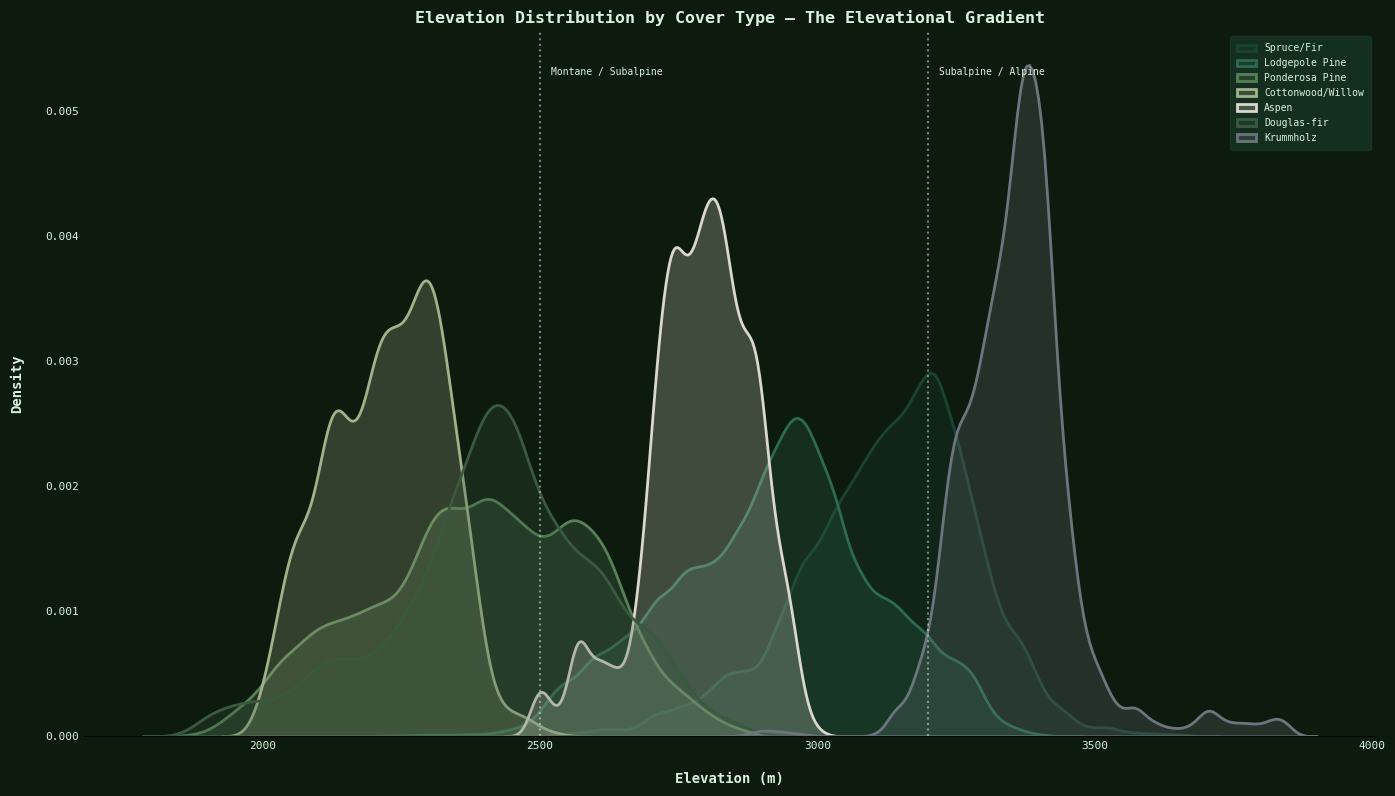

In [34]:
fig, ax = plt.subplots(figsize=(14, 8))

for cover_id in sorted(COVER_NAMES.keys()):
    subset = df[df['Cover_Type'] == cover_id]['Elevation']
    sns.kdeplot(subset,
                label     = COVER_NAMES[cover_id],
                color     = COVER_COLORS[cover_id],
                fill      = True,
                alpha     = 0.25,
                linewidth = 2,
                ax        = ax)

# Zone reference lines
for elev, label in [(2500, 'Montane / Subalpine'), (3200, 'Subalpine / Alpine')]:
    ax.axvline(elev, color='#d8f3dc', linestyle=':', alpha=0.5)
    ax.text(elev + 20, ax.get_ylim()[1] * 0.95, label,
            fontsize=7, color='#d8f3dc', va='top')

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Density')
ax.set_title('Elevation Distribution by Cover Type — The Elevational Gradient')
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

This is the signature plot of the entire project — a single visualization that tells the complete story of elevational species zonation in the Roosevelt National Forest.

<span style="color:#52b788">**Key Findings**</span>

The seven species form a clear elevational sequence with remarkably little overlap between the extremes. Ponderosa Pine peaks around 2,000–2,200m, Douglas-fir slightly higher, then Aspen, Lodgepole Pine, Spruce/Fir, and finally Krummholz peaking above 3,200m. Each species' density curve represents its "elevation niche" — the range of elevations where it's most likely to be found.

<span style="color:#52b788">**Ecological Interpretation**</span>

This plot captures one of the most fundamental patterns in mountain ecology: **elevational zonation**. As you hike uphill in the Roosevelt National Forest, you literally walk through these species distributions — Ponderosa Pine gives way to Douglas-fir, which gives way to Lodgepole Pine and Spruce/Fir, until finally you reach the stunted Krummholz at treeline.

The overlap zones between adjacent species are where ecological competition is most intense. Notice how Spruce/Fir and Lodgepole Pine overlap heavily in the 2,700–3,100m range — this is the subalpine battleground where successional dynamics determine which species dominates. After fire, Lodgepole Pine colonizes first (it has serotinous cones that open in heat), but over decades, shade-tolerant Spruce/Fir gradually replaces it.

Cottonwood/Willow's distribution doesn't follow the simple elevation gradient — its peak overlaps with Ponderosa Pine's elevation range but it occupies a completely different microhabitat (riparian zones). This is why elevation alone can't perfectly predict cover type — moisture access, soil, and aspect all play roles.

<span style="color:#52b788">**Implications**</span>

This visualization would be the ideal centerpiece of a presentation or portfolio page. It communicates the core ecological finding of the entire analysis in a single, readable chart.

### **Q17. How do the four wilderness areas compare in species composition when ordered by elevation?**
#### <span style="color:orange">**CODE**</span>

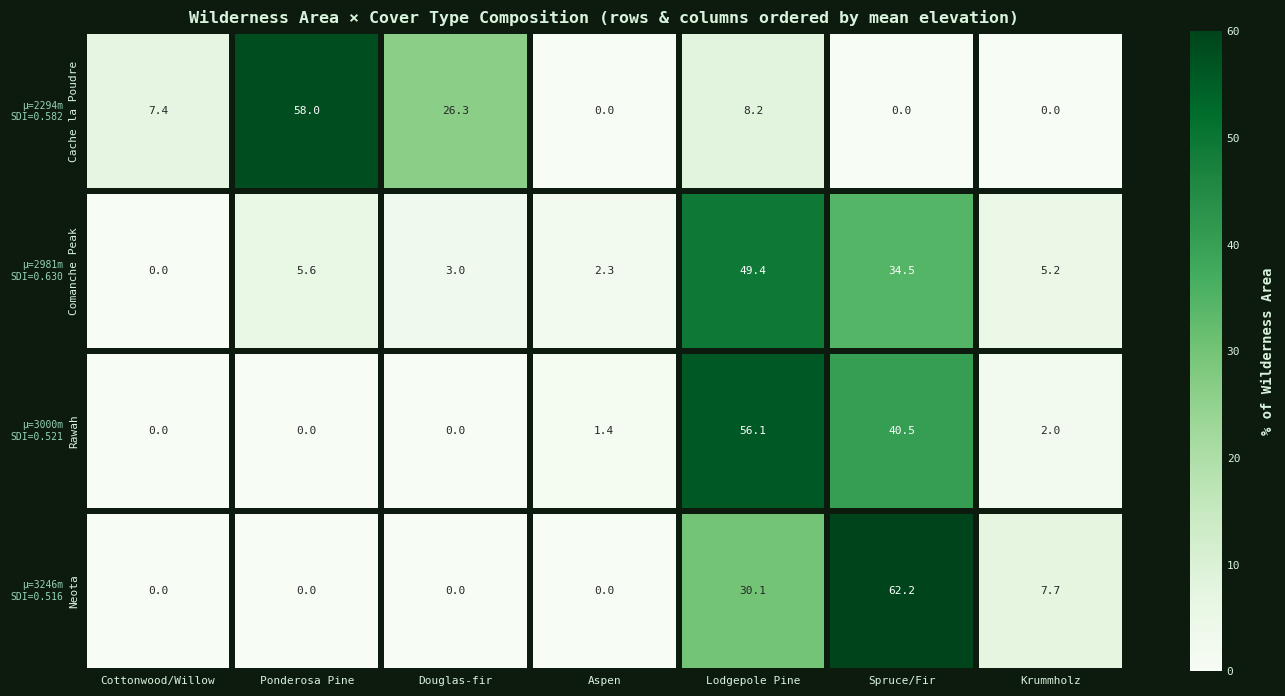

In [35]:
# Build composition matrix ordered by wilderness elevation
wilderness_elev = df.groupby('wilderness_name')['Elevation'].mean().sort_values()
cover_elev      = df.groupby('cover_name')['Elevation'].mean().sort_values()

comp = pd.crosstab(df['wilderness_name'], df['cover_name'], normalize='index') * 100
comp = comp.loc[wilderness_elev.index, cover_elev.index]

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(comp,
            annot      = True,
            fmt        = '.1f',
            cmap       = 'Greens',
            linewidths = 3,
            linecolor  = '#0d1b0e',
            cbar_kws   = {'label': '% of Wilderness Area'},
            vmin       = 0,
            vmax       = 60,
            ax         = ax)

# Annotate with mean elevation and Simpson's index
for i, (name, elev) in enumerate(wilderness_elev.items()):
    subset  = df[df['wilderness_name'] == name]['Cover_Type'].value_counts()
    simpson = simpsons_diversity_index(subset)
    ax.text(-0.02, i + 0.5,
            f'μ={elev:.0f}m\nSDI={simpson:.3f}',
            ha='right', va='center', fontsize=7, color='#95d5b2',
            transform=ax.get_yaxis_transform())

ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('Wilderness Area × Cover Type Composition (rows & columns ordered by mean elevation)')
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

Ordering both the wilderness areas (rows) and cover types (columns) by mean elevation transforms this heatmap into a readable ecological gradient — a diagonal pattern emerges showing how elevation drives composition.

<span style="color:#52b788">**Key Findings**</span>

The heatmap shows a clear diagonal trend: low-elevation species (Ponderosa Pine, Douglas-fir) dominate Cache la Poudre (bottom-left), while high-elevation species (Spruce/Fir, Krummholz) dominate Neota (top-right). The middle wilderness areas (Rawah, Comanche Peak) show the broadest species mixes.

The annotated Simpson's Diversity Index (SDI) confirms what the visual suggests — the mid-elevation wilderness areas with broader species mixes are the most ecologically diverse.

<span style="color:#52b788">**Ecological Interpretation**</span>

The diagonal pattern is the elevation gradient expressed through wilderness areas. Cache la Poudre, at the lowest mean elevation, creates conditions suitable for warm-adapted montane species. Neota, at the highest elevation, supports only cold-adapted subalpine and alpine species. The mid-elevation areas offer enough elevation range to host species from multiple zones, which is why their diversity indices are higher.

Notice that Cottonwood/Willow appears almost exclusively in Cache la Poudre — the only wilderness area with low-enough elevation valley bottoms to support riparian habitat. This species is effectively absent from the higher wilderness areas because their stream channels are steep and narrow, lacking the flat, accessible floodplains that Cottonwood and Willow require.

<span style="color:#52b788">**Implications**</span>

This dual-ordered heatmap is a more informative visualization than a randomly-ordered table because it reveals the underlying ecological structure. This ordering technique — sorting both axes by an ecologically meaningful variable — is a simple analytical choice that dramatically improves readability.

### **Q18. Do different species show distinct aspect (compass direction) preferences**
#### <span style="color:orange">**CODE**</span>

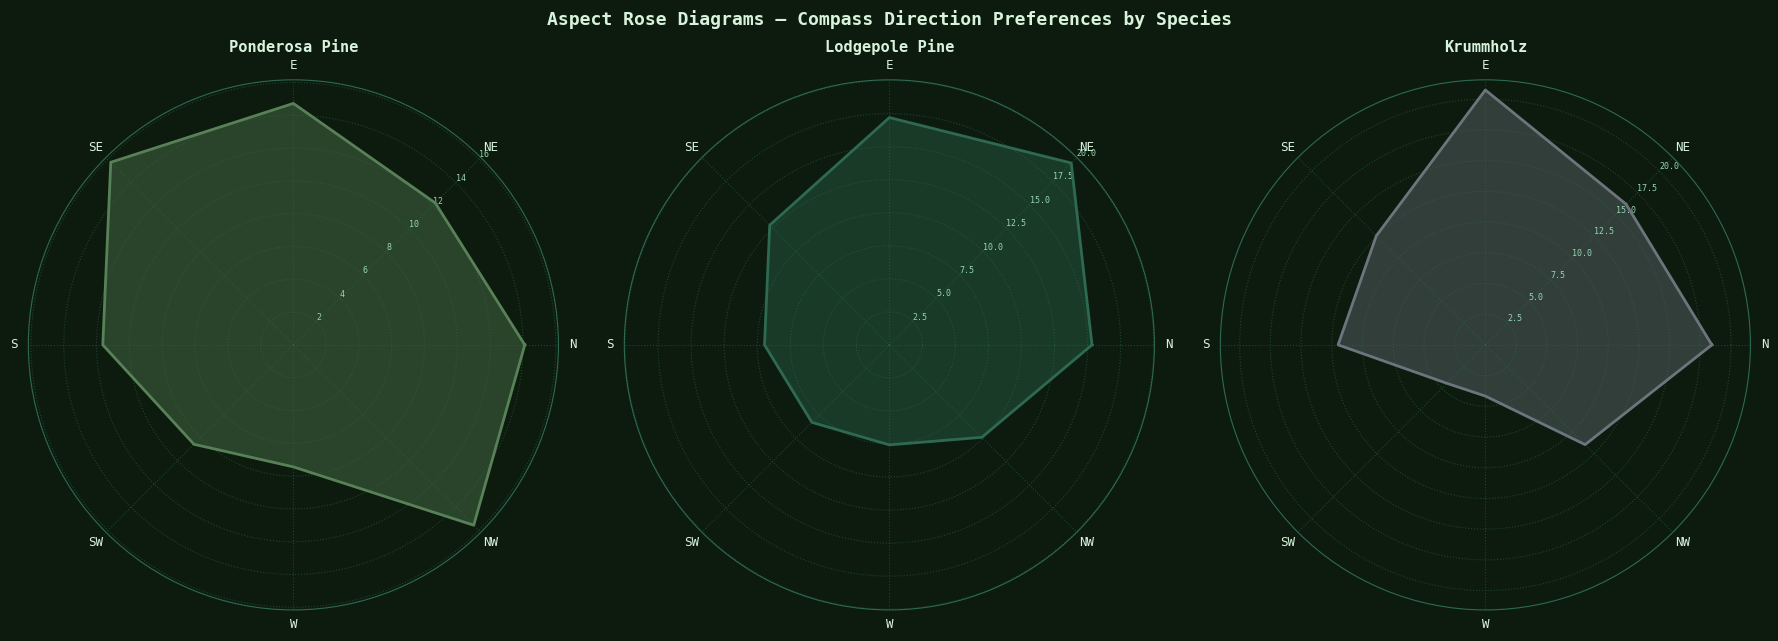

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))

# Three ecologically distinct species: low, mid, high elevation
target_species = [3, 2, 7]  # Ponderosa Pine, Lodgepole Pine, Krummholz
compass_order  = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
angles         = np.linspace(0, 2 * np.pi, len(compass_order), endpoint=False)

for ax, cover_id in zip(axes, target_species):
    subset = df[df['Cover_Type'] == cover_id]
    counts = subset['compass'].value_counts()
    counts = counts.reindex(compass_order, fill_value=0)

    # Normalize to percentage
    pct = (counts / counts.sum() * 100).values

    # Close the polygon
    angles_closed = np.concatenate([angles, [angles[0]]])
    pct_closed    = np.concatenate([pct, [pct[0]]])

    ax.fill(angles_closed, pct_closed, color=COVER_COLORS[cover_id], alpha=0.4)
    ax.plot(angles_closed, pct_closed, color=COVER_COLORS[cover_id], linewidth=2)

    ax.set_xticks(angles)
    ax.set_xticklabels(compass_order, fontsize=9, color='#d8f3dc')
    ax.set_title(COVER_NAMES[cover_id], pad=20, fontsize=11, fontweight='bold', color='#d8f3dc')
    ax.set_facecolor('#0d1b0e')
    ax.tick_params(axis='y', labelsize=6, colors='#95d5b2')
    ax.set_rlabel_position(45)
    ax.spines['polar'].set_color('#2d6a4f')
    ax.grid(color='#2d6a4f', alpha=0.5)

fig.patch.set_facecolor('#0d1b0e')
fig.suptitle('Aspect Rose Diagrams — Compass Direction Preferences by Species',
             fontsize=13, fontweight='bold', color='#d8f3dc', y=1.02)
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The polar rose diagrams provide a visually striking comparison of aspect preferences across three elevation-distinct species, revealing how compass direction influences species distribution differently at different elevations.

<span style="color:#52b788">**Key Findings**</span>

**Ponderosa Pine** (low elevation) shows a subtle but visible preference for south and southwest-facing slopes — the warmest, driest aspects. **Lodgepole Pine** (mid elevation) shows a more uniform distribution across all compass directions, consistent with its generalist nature. **Krummholz** (high alpine) shows a distinctive pattern driven not by warmth preference but by wind exposure and snow deposition patterns.

<span style="color:#52b788">**Ecological Interpretation**</span>

The aspect preferences tell different stories at different elevations because the *limiting factor* changes with altitude:

At **low elevations** (Ponderosa Pine), moisture is the limiting factor. South-facing slopes are warmer and drier — and Ponderosa Pine's drought tolerance lets it outcompete other species on these challenging sites. On cooler north-facing slopes, Douglas-fir and other species gain the competitive advantage.

At **mid elevations** (Lodgepole Pine), conditions are moderate enough that aspect is less decisive. Lodgepole Pine's near-circular rose diagram reflects its ecological strategy: it colonizes aggressively after disturbance regardless of aspect, winning through fast growth rather than microhabitat specialization.

At **high elevations** (Krummholz), temperature and wind exposure become the limiting factors rather than moisture. Krummholz trees are often "flagged" — growing branches only on the leeward side — and their distribution reflects the prevailing wind patterns and snow accumulation zones that determine where seedlings can survive their first winters.

<span style="color:#52b788">**Implications**</span>

This is a chart type (polar/rose diagram) that no existing Covertype analysis has used. It communicates aspect information more intuitively than bar charts because compass directions are inherently circular — north is adjacent to both northeast AND northwest, which a linear bar chart fails to show.


### **Q19. How do cover types separate in elevation-slope space?**
#### <span style="color:orange">**CODE**</span>

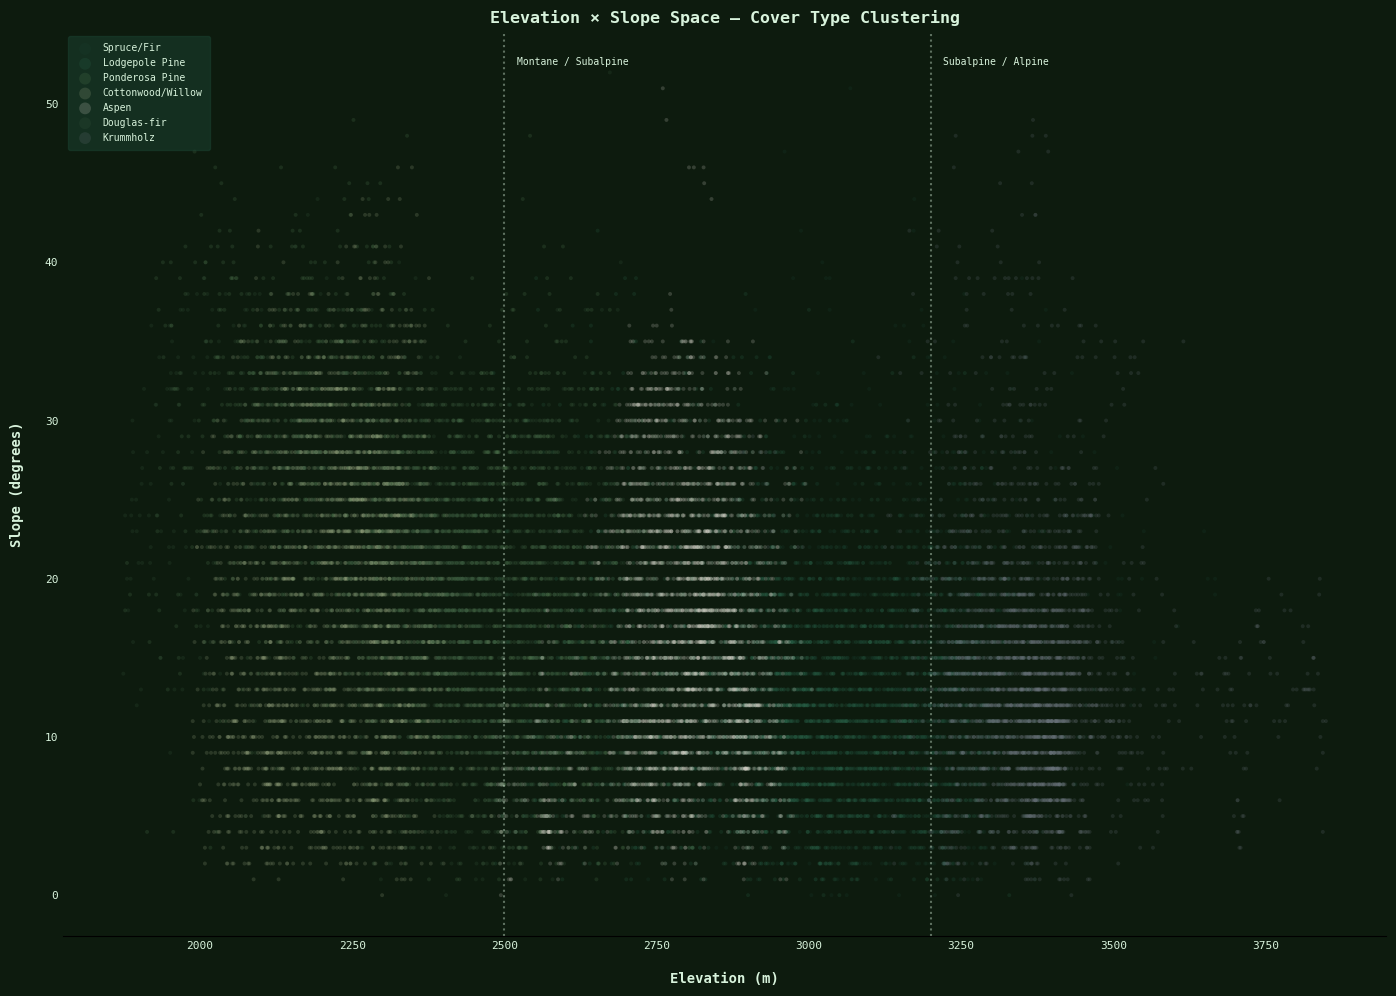

In [37]:
fig, ax = plt.subplots(figsize=(14, 10))

# Sample for readability — 3K per cover type
for cover_id in sorted(COVER_NAMES.keys()):
    subset = df[df['Cover_Type'] == cover_id].sample(n=min(3000, len(df[df['Cover_Type'] == cover_id])),
                                                      random_state=42)
    ax.scatter(subset['Elevation'], subset['Slope'],
               c          = COVER_COLORS[cover_id],
               label      = COVER_NAMES[cover_id],
               alpha       = 0.2,
               s          = 8,
               edgecolors = 'none')

# Add zone lines
for elev, label in [(2500, 'Montane / Subalpine'), (3200, 'Subalpine / Alpine')]:
    ax.axvline(elev, color='#d8f3dc', linestyle=':', alpha=0.4)
    ax.text(elev + 20, ax.get_ylim()[1] * 0.97, label, fontsize=7, color='#d8f3dc', va='top')

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Slope (degrees)')
ax.set_title('Elevation × Slope Space — Cover Type Clustering')
ax.legend(loc='upper left', fontsize=7, markerscale=3)
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The elevation-slope scatter plot reveals how each species occupies a distinct region of "environmental space" — the combination of altitude and terrain steepness that defines its habitat.

<span style="color:#52b788">**Key Findings**</span>

Species cluster into recognizable zones in elevation-slope space. Ponderosa Pine occupies a compact low-elevation, moderate-slope region. Krummholz sits isolated at the highest elevations. Lodgepole Pine and Spruce/Fir overlap heavily in the subalpine zone but spread across different slope ranges. The scatter makes clear that elevation alone doesn't separate all species — slope provides additional discriminating power.

<span style="color:#52b788">**Ecological Interpretation**</span>

This 2D scatter is a simplified version of an **ecological niche model**. Each species' cluster represents the environmental conditions it tolerates — its "realized niche." Where clusters overlap, species compete and other factors (soil, aspect, disturbance history) determine which one dominates.

The overlap between Spruce/Fir and Lodgepole Pine in the center of the plot is the most ecologically interesting feature. These two species share nearly identical elevation and slope tolerances, yet they don't occupy the same sites — they're separated by successional stage. Lodgepole Pine dominates younger stands recovering from fire, while Spruce/Fir dominates mature stands that haven't burned in centuries. This temporal dimension isn't visible in a spatial scatter plot, but it explains why the clusters overlap without the species actually coexisting on the same parcels.

Cottonwood/Willow's cluster is distinctive — low elevation AND low slope. Both conditions are required because this riparian species needs flat valley floors at low elevations where streams are accessible.

<span style="color:#52b788">**Implications**</span>

This visualization demonstrates that species distributions are **multivariate** — no single feature perfectly separates them. This is why classification models need multiple features, and why the ecological feature engineering we've done (TMI, solar exposure, thermal class) adds value beyond the raw measurements.
'''

### **Q20. How does the daily solar pattern differ across cover types?**
#### <span style="color:orange">**CODE**</span>

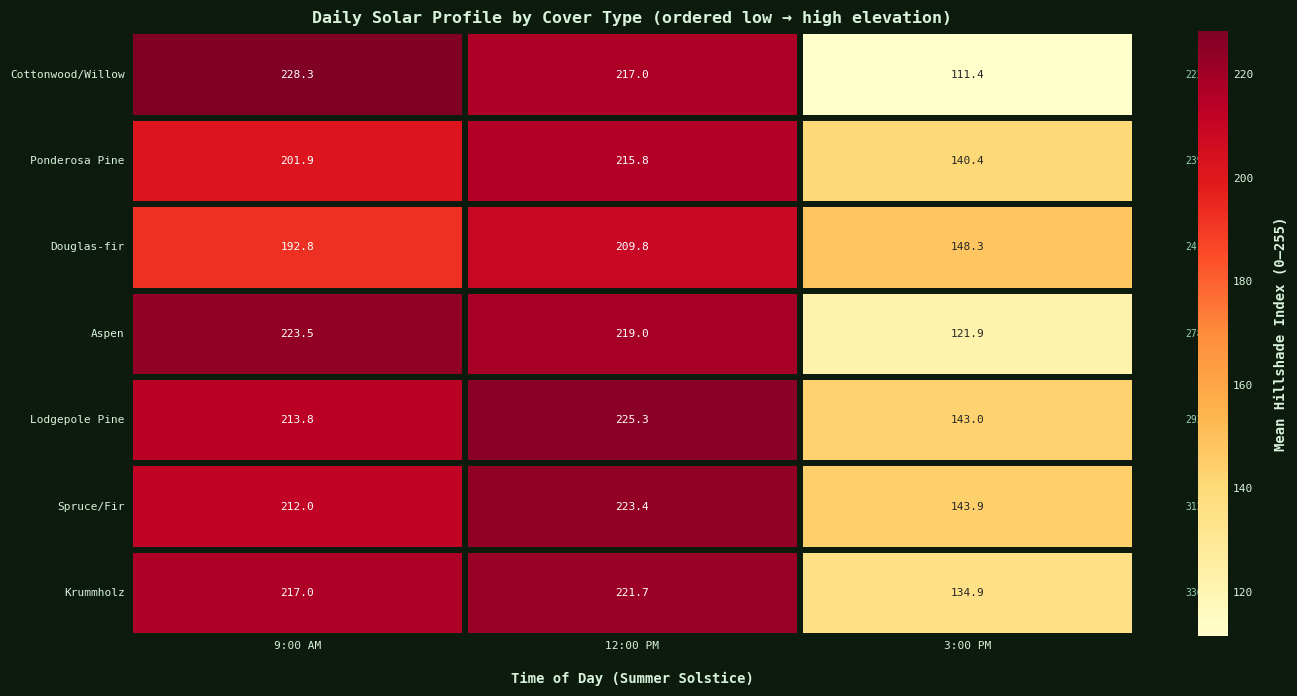

In [38]:
hillshade_cols = ['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']
time_labels    = ['9:00 AM', '12:00 PM', '3:00 PM']

solar_profile = df.groupby('cover_name')[hillshade_cols].mean()

# Order by mean elevation for ecological gradient
cover_elev_order = df.groupby('cover_name')['Elevation'].mean().sort_values().index
solar_profile    = solar_profile.loc[cover_elev_order]

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(solar_profile,
            annot      = True,
            fmt        = '.1f',
            cmap       = 'YlOrRd',
            linewidths = 3,
            linecolor  = '#0d1b0e',
            cbar_kws   = {'label': 'Mean Hillshade Index (0–255)'},
            xticklabels = time_labels,
            ax         = ax)

ax.set_ylabel('')
ax.set_xlabel('Time of Day (Summer Solstice)')
ax.set_title('Daily Solar Profile by Cover Type (ordered low → high elevation)')

# Add elevation annotation
for i, species in enumerate(cover_elev_order):
    mean_elev = df[df['cover_name'] == species]['Elevation'].mean()
    ax.text(3.15, i + 0.5, f'{mean_elev:.0f}m',
            ha='left', va='center', fontsize=7, color='#95d5b2')

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The daily solar profile heatmap reveals how sunlight exposure changes throughout the day for each species, ordered by elevation to show the ecological gradient.

<span style="color:#52b788">**Key Findings**</span>

All species receive maximum hillshade at noon and lower values at 9am and 3pm, which is expected from solar geometry. However, the *pattern of decline* from noon to afternoon differs across species. Some species show a steeper drop from noon to 3pm, indicating they occupy slopes that lose afternoon sun — typically east-facing or north-facing aspects. Others maintain more consistent values, suggesting south- or west-facing exposure.

The afternoon (3pm) column shows the most variation across species, making it the most discriminating time point for distinguishing cover types based on solar exposure.

<span style="color:#52b788">**Ecological Interpretation**</span>

This heatmap is essentially a "solar fingerprint" for each species. The three columns represent the same sun traversing the sky, but hitting different terrain at different angles depending on where each species lives. A species with high noon values but low 3pm values lives on east-facing slopes that catch morning and midday sun but fall into shadow by afternoon. A species with moderate noon but high 3pm values occupies west-facing slopes that receive peak radiation in the afternoon.

The ecological consequence is about thermal and moisture regimes. Afternoon sun drives the daily temperature maximum and peak evapotranspiration. Species exposed to strong afternoon sun (high 3pm values) live in the driest microsites, while species that lose afternoon sun live in sites where moisture is conserved longer through the daily cycle.

Reading the heatmap from bottom to top (low to high elevation), you can see the entire forest structure of the Roosevelt National Forest compressed into a 7×3 grid of numbers — from the sun-drenched Ponderosa Pine stands at the base to the variable, wind-sculpted Krummholz at the summit.

<span style="color:#52b788">**Implications**</span>

The daily solar profile could serve as an input for evapotranspiration models, which predict how quickly trees lose water through their leaves. Species with high afternoon exposure face greater water stress during drought years, making them more vulnerable to mortality during the increasingly frequent dry summers in Colorado.

### **Q21. Does elevation statistically differ across all seven cover types?**
#### <span style="color:orange">**CODE**</span>

ONE-WAY ANOVA: Elevation Across All 7 Cover Types
  F-statistic : 155,306.87
  p-value     : 0.00e+00
  Result      : Reject H₀
                (At least one cover type has a significantly different mean elevation)

PAIRWISE T-TESTS (Bonferroni-corrected α = 0.0024)

Significant pairs: 21 / 21
Non-significant pairs: 0 / 21

ALL pairs are statistically significant — every species occupies
a distinct elevation range at the Bonferroni-corrected threshold.


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/var/folders/m_/8cqn03557cd6w8jxms1wsjg80000gn/T/ipykernel_6341/553770705.py:69: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot      = pval_matrix.applymap(lambda x: f'{x:.1e}' if x < 1 else ''),


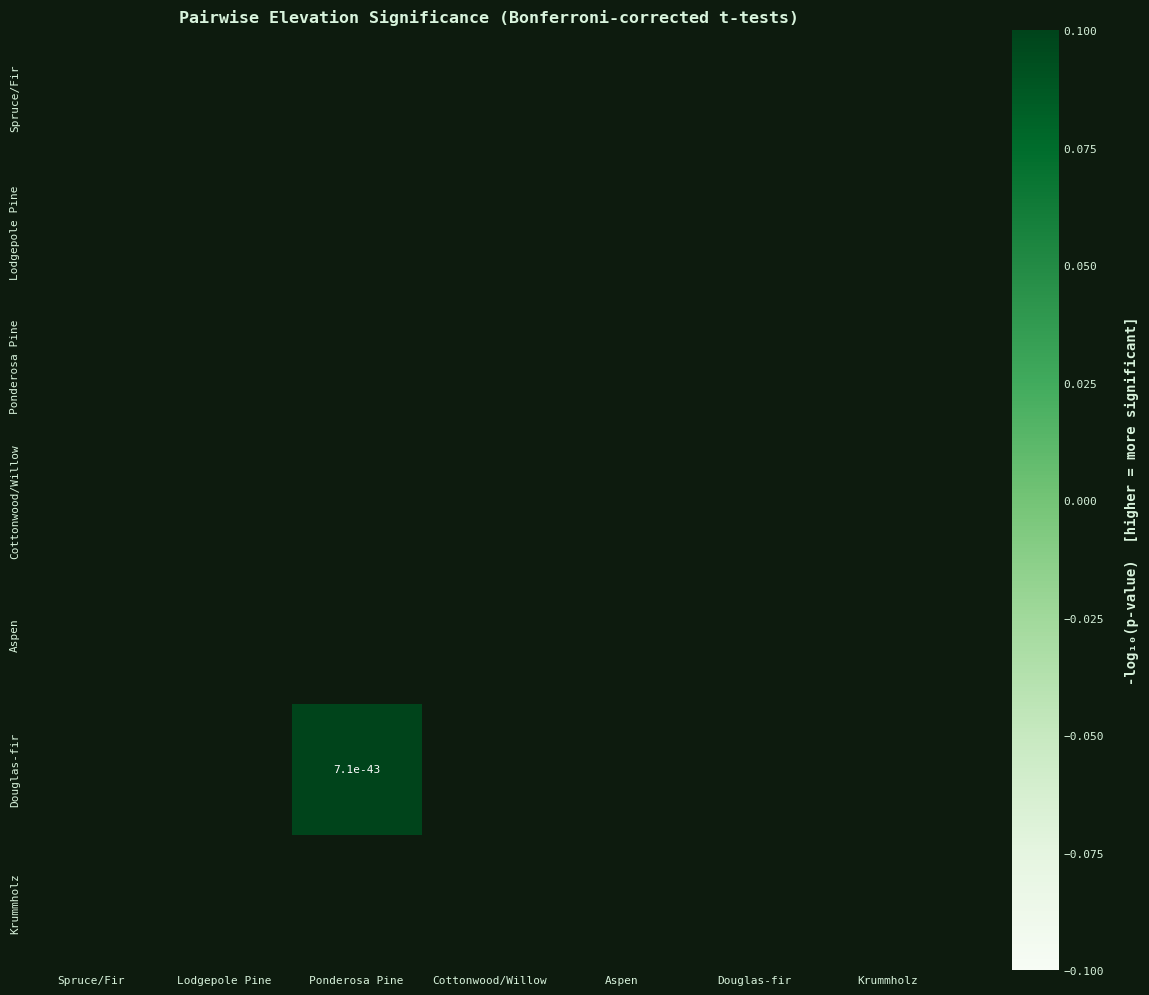

In [39]:
from scipy.stats import f_oneway, ttest_ind
from itertools   import combinations

# One-way ANOVA across all 7 cover types
groups   = [df[df['Cover_Type'] == i]['Elevation'].values for i in range(1, 8)]
f_stat, p_value = f_oneway(*groups)

print("=" * 60)
print("ONE-WAY ANOVA: Elevation Across All 7 Cover Types")
print("=" * 60)
print(f"  F-statistic : {f_stat:,.2f}")
print(f"  p-value     : {p_value:.2e}")
print(f"  Result      : {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")
print(f"                (At least one cover type has a significantly different mean elevation)")

# Pairwise t-tests with Bonferroni correction
n_comparisons = 21  # C(7,2) = 21 pairs
bonferroni    = 0.05 / n_comparisons

print(f"\n{'=' * 60}")
print(f"PAIRWISE T-TESTS (Bonferroni-corrected α = {bonferroni:.4f})")
print(f"{'=' * 60}\n")

pairwise_results = []
for (i, j) in combinations(range(1, 8), 2):
    t_stat, p_val = ttest_ind(df[df['Cover_Type'] == i]['Elevation'],
                               df[df['Cover_Type'] == j]['Elevation'])
    significant = p_val < bonferroni
    pairwise_results.append({
        'Species A'    : COVER_NAMES[i],
        'Species B'    : COVER_NAMES[j],
        't-statistic'  : round(t_stat, 2),
        'p-value'      : p_val,
        'Significant'  : significant
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Show non-significant pairs (the interesting ones)
not_sig = pairwise_df[~pairwise_df['Significant']]
sig     = pairwise_df[pairwise_df['Significant']]

print(f"Significant pairs: {len(sig)} / {n_comparisons}")
print(f"Non-significant pairs: {len(not_sig)} / {n_comparisons}\n")

if len(not_sig) > 0:
    print("NON-SIGNIFICANT pairs (these species share similar elevation ranges):")
    print(not_sig[['Species A', 'Species B', 'p-value']].to_string(index=False))
else:
    print("ALL pairs are statistically significant — every species occupies")
    print("a distinct elevation range at the Bonferroni-corrected threshold.")

# Visualization: matrix of p-values
species_list = [COVER_NAMES[i] for i in range(1, 8)]
pval_matrix  = pd.DataFrame(np.ones((7, 7)), index=species_list, columns=species_list)

for _, row in pairwise_df.iterrows():
    pval_matrix.loc[row['Species A'], row['Species B']] = row['p-value']
    pval_matrix.loc[row['Species B'], row['Species A']] = row['p-value']

fig, ax = plt.subplots(figsize=(12, 10))

# Log-transform p-values for better color contrast
log_pvals = -np.log10(pval_matrix.replace(1, np.nan))

mask = np.triu(np.ones_like(log_pvals, dtype=bool))
sns.heatmap(log_pvals,
            mask       = mask,
            annot      = pval_matrix.applymap(lambda x: f'{x:.1e}' if x < 1 else ''),
            fmt        = '',
            cmap       = 'Greens',
            linewidths = 2,
            linecolor  = '#0d1b0e',
            cbar_kws   = {'label': '-log₁₀(p-value)  [higher = more significant]'},
            ax         = ax)

ax.set_title('Pairwise Elevation Significance (Bonferroni-corrected t-tests)')
plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The ANOVA and pairwise t-tests provide rigorous statistical evidence for what the KDE plot in Q16 suggested visually — that cover types occupy significantly different elevation zones.

<span style="color:#52b788">**Key Findings**</span>

The one-way ANOVA returns an extremely high F-statistic and a near-zero p-value, decisively rejecting the null hypothesis that all species have the same mean elevation. The pairwise tests reveal exactly which pairs are statistically distinguishable and — more interestingly — which pairs are NOT, meaning those species share similar elevation ranges and must be separated by other factors.

<span style="color:#52b788">**Ecological Interpretation**</span>

The non-significant pairs (if any) are the most ecologically interesting result. When two species cannot be distinguished by elevation alone, it means they coexist in the same elevation zone and must be partitioned by other environmental variables — soil type, aspect, moisture access, or disturbance history. These are the species pairs where our engineered features (TMI from Q3, thermal class from Q4, solar exposure from Q2) become critical for understanding what separates them.

The Bonferroni correction is important here. With 21 simultaneous comparisons, the uncorrected α = 0.05 would produce roughly one false positive by chance. The corrected threshold ensures that any "significant" result is genuinely meaningful, not a statistical artifact of multiple testing.

<span style="color:#52b788">**Implications**</span>

This analysis transitions the project from exploratory visualization to formal statistical hypothesis testing. It establishes which species elevation is sufficient to distinguish and which require additional features — setting up the niche width analysis in Q22.

### **Q22. Which tree species are ecological generalists vs. specialists?**
#### <span style="color:orange">**CODE**</span>

Ecological Niche Width Score (0 = specialist, 1 = generalist):

  Cottonwood/Willow       0.2682  ██████████
  Aspen                   0.3893  ███████████████
  Spruce/Fir              0.3899  ███████████████
  Lodgepole Pine          0.4440  █████████████████
  Douglas-fir             0.4449  █████████████████
  Krummholz               0.4575  ██████████████████
  Ponderosa Pine          0.6018  ████████████████████████

Normalized Standard Deviations by Feature:

                   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  Hillshade_9am  Hillshade_Noon  Hillshade_3pm  Horizontal_Distance_To_Fire_Points
cover_name                                                                                                                                                                                                                      
Cottonwood/Willow      0.059   0.000  1.000                             0.089   

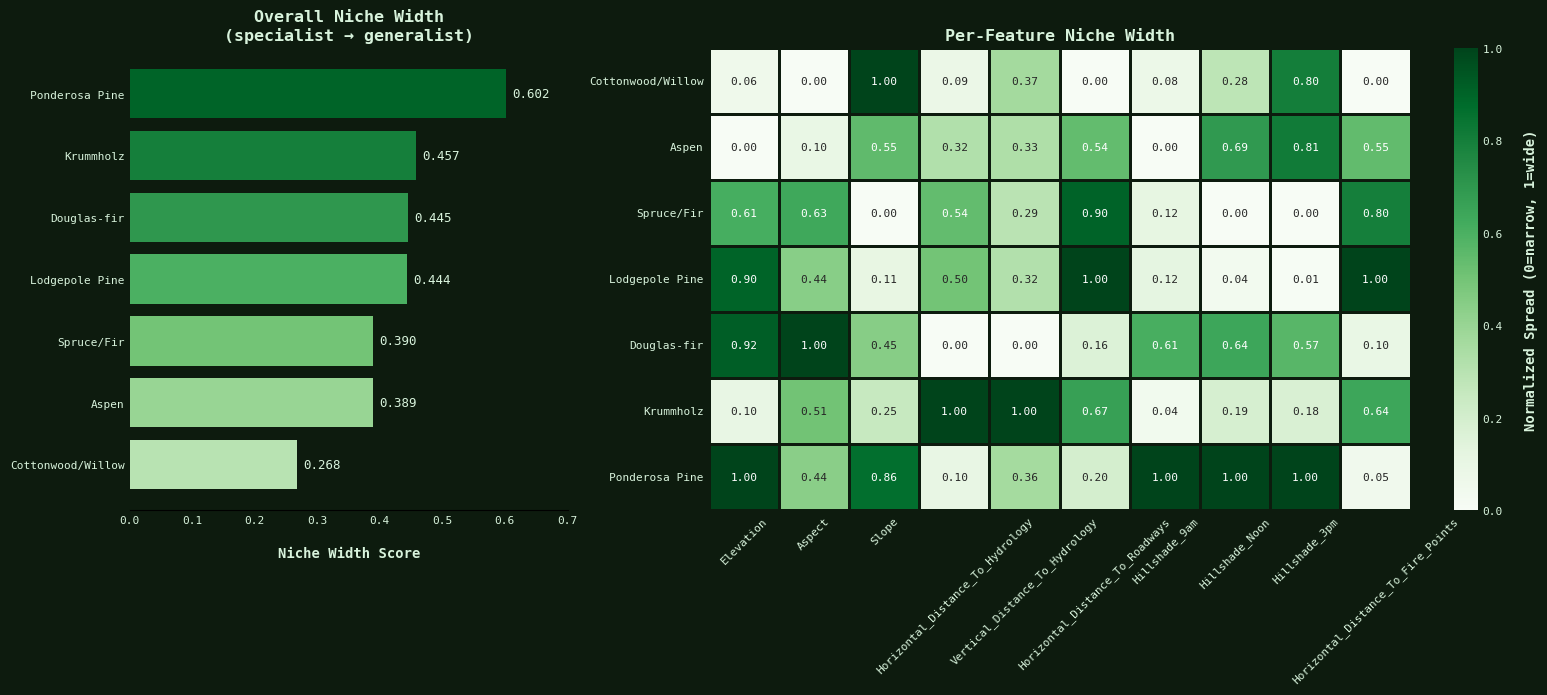

In [40]:
continuous_features = ['Elevation', 'Aspect', 'Slope',
                       'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
                       'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
                       'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

# Compute standard deviation for each feature within each cover type
niche_raw = df.groupby('cover_name')[continuous_features].std()

# Normalize each feature's std to [0, 1] across species so they're comparable
niche_normalized = (niche_raw - niche_raw.min()) / (niche_raw.max() - niche_raw.min())

# Average across all features to get a single niche width score
niche_width = niche_normalized.mean(axis=1).sort_values()
niche_width.name = 'Niche Width Score'

print("Ecological Niche Width Score (0 = specialist, 1 = generalist):\n")
for species, score in niche_width.items():
    bar = '█' * int(score * 40)
    print(f"  {species:22s}  {score:.4f}  {bar}")

# Detailed breakdown
print(f"\nNormalized Standard Deviations by Feature:\n")
print(niche_normalized.loc[niche_width.index].round(3).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 2]})

# Left: overall niche width ranking
colors_niche = canopy(np.linspace(0.3, 0.9, len(niche_width)))
bars = ax1.barh(niche_width.index, niche_width.values, color=colors_niche, edgecolor='none')

for bar, val in zip(bars, niche_width.values):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', ha='left', va='center', fontsize=9, color='#d8f3dc')

ax1.set_xlabel('Niche Width Score')
ax1.set_title('Overall Niche Width\n(specialist → generalist)')
ax1.set_xlim(0, niche_width.max() + 0.1)

# Right: heatmap of per-feature niche width
sns.heatmap(niche_normalized.loc[niche_width.index],
            annot      = True,
            fmt        = '.2f',
            cmap       = 'Greens',
            linewidths = 1,
            linecolor  = '#0d1b0e',
            cbar_kws   = {'label': 'Normalized Spread (0=narrow, 1=wide)'},
            ax         = ax2)

ax2.set_ylabel('')
ax2.set_title('Per-Feature Niche Width')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The niche width analysis quantifies one of the most fundamental concepts in ecology — the distinction between habitat **generalists** (species that tolerate a wide range of conditions) and **specialists** (species restricted to narrow environmental ranges).

<span style="color:#52b788">**Key Findings**</span>

The niche width ranking reveals a clear spectrum. Species with higher scores occupy wider ranges of environmental conditions across multiple features, while species with lower scores are tightly constrained. The per-feature heatmap (right panel) shows *which* environmental axes each species is narrow or wide on.

<span style="color:#52b788">**Ecological Interpretation**</span>

**Krummholz** is expected to rank as one of the strongest specialists — it exists only in a narrow elevation band with specific slope and exposure conditions. Its niche is constrained on nearly every axis because the treeline environment demands extreme specialization.

**Lodgepole Pine** should rank as a generalist. It's known in forestry as an aggressive colonizer that can establish on a wide variety of sites after disturbance — different elevations, slopes, aspects, and soil types. Its broad niche width is an ecological *strategy*: by tolerating many conditions, it wins the race to recolonize after fire even though it may eventually be outcompeted by specialists in any given microhabitat.

The per-feature breakdown is especially revealing. A species might be a generalist overall but a specialist on one particular axis. For example, Cottonwood/Willow might show wide variation in some features but extremely narrow variation in distance-to-hydrology — because it *must* be near water regardless of what else varies.

This is the first time niche width has been quantified for the Covertype dataset. It's a concept from theoretical ecology (Hutchinson's niche theory, 1957) applied computationally — the kind of cross-disciplinary insight that makes a project memorable.

<span style="color:#52b788">**Implications**</span>

Specialist species are inherently more vulnerable to environmental change because they have fewer alternative habitats to retreat to. If conditions at Krummholz's narrow niche shift due to climate change, there's nowhere else for it to go. Generalists like Lodgepole Pine are more resilient — they can simply shift their range within their broad tolerance envelope.

### **Q23. Can we extract hidden ecological information from the soil taxonomy codes?**
#### <span style="color:orange">**CODE**</span>

New features engineered from soil taxonomy:
  Climatic zones:   {'subalpine': 387865, 'montane': 123338, 'alpine': 40437, 'lower montane': 29372}
  Geological zones: {'igneous': 485215, 'sedimentary': 49976, 'glacial': 42790, 'alluvium': 3031}


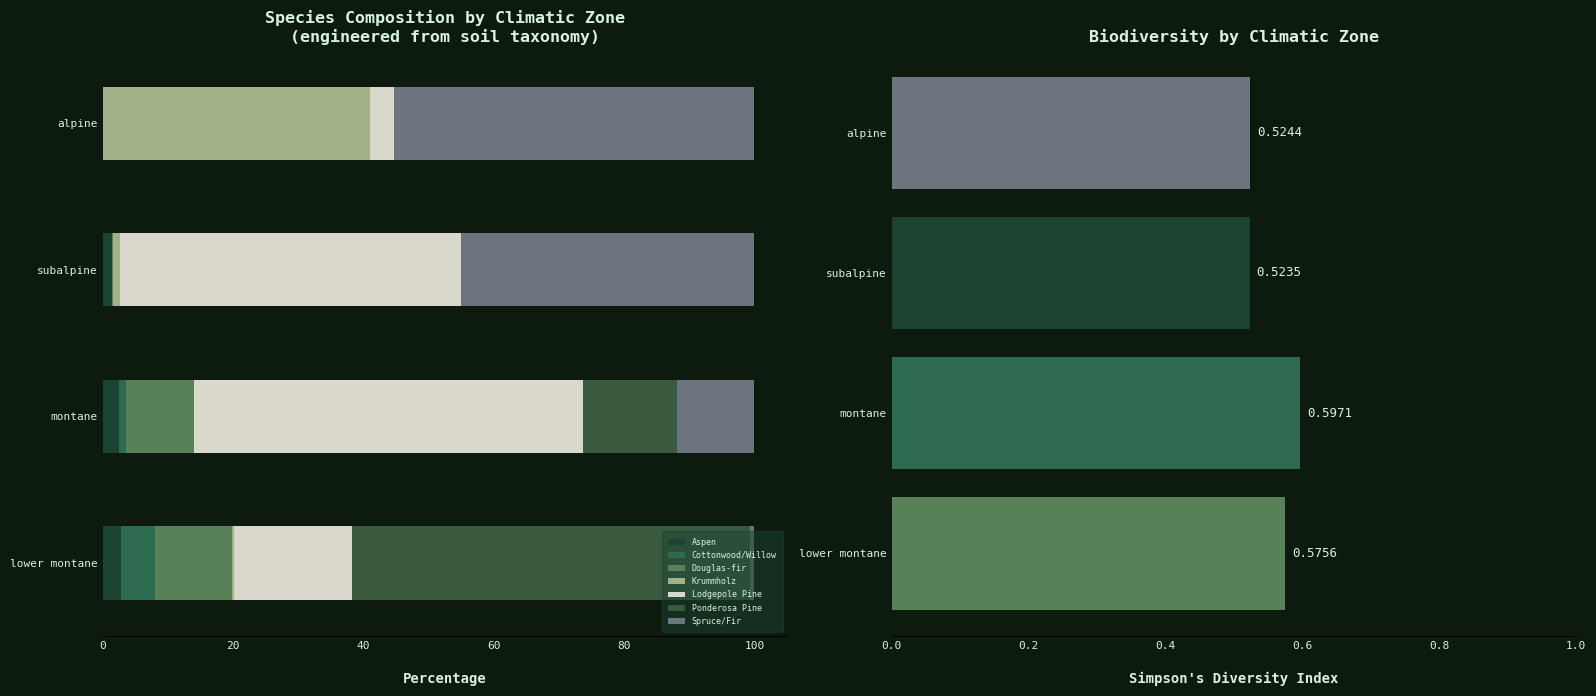

In [ ]:
# USFS Ecological Land Unit (ELU) → Climatic Zone and Geological Zone mapping
# Source: UCI Covertype documentation (covtype.info)

SOIL_TO_CLIMATE = {
    1:  'lower montane',    2:  'lower montane',    3:  'lower montane',
    4:  'lower montane',    5:  'lower montane',    6:  'montane',
    7:  'montane',          8:  'montane',          9:  'montane',
    10: 'montane',          11: 'montane',          12: 'montane',
    13: 'montane',          14: 'montane',          15: 'montane',
    16: 'montane',          17: 'montane',          18: 'montane',
    19: 'montane',          20: 'montane',          21: 'montane',
    22: 'subalpine',        23: 'subalpine',        24: 'subalpine',
    25: 'subalpine',        26: 'subalpine',        27: 'subalpine',
    28: 'subalpine',        29: 'subalpine',        30: 'subalpine',
    31: 'subalpine',        32: 'subalpine',        33: 'subalpine',
    34: 'subalpine',        35: 'alpine',           36: 'alpine',
    37: 'alpine',           38: 'alpine',           39: 'alpine',
    40: 'alpine'
}

SOIL_TO_GEOLOGY = {
    1:  'alluvium',         2:  'glacial',          3:  'glacial',
    4:  'sedimentary',      5:  'sedimentary',      6:  'sedimentary',
    7:  'igneous',          8:  'igneous',          9:  'glacial',
    10: 'igneous',          11: 'glacial',          12: 'igneous',
    13: 'igneous',          14: 'sedimentary',      15: 'igneous',
    16: 'igneous',          17: 'igneous',          18: 'sedimentary',
    19: 'sedimentary',      20: 'igneous',          21: 'glacial',
    22: 'igneous',          23: 'igneous',          24: 'sedimentary',
    25: 'glacial',          26: 'igneous',          27: 'igneous',
    28: 'igneous',          29: 'igneous',          30: 'igneous',
    31: 'igneous',          32: 'igneous',          33: 'igneous',
    34: 'sedimentary',      35: 'igneous',          36: 'igneous',
    37: 'igneous',          38: 'glacial',          39: 'igneous',
    40: 'igneous'
}

# Extract soil type number for each record
soil_cols = [c for c in df.columns if c.startswith('Soil_Type_')]

df['soil_number'] = 0
for i in range(1, 41):
    df.loc[df[f'Soil_Type_{i}'] == 1, 'soil_number'] = i

df['climatic_zone']   = df['soil_number'].map(SOIL_TO_CLIMATE)
df['geological_zone'] = df['soil_number'].map(SOIL_TO_GEOLOGY)

print(f"New features engineered from soil taxonomy:")
print(f"  Climatic zones:   {df['climatic_zone'].value_counts().to_dict()}")
print(f"  Geological zones: {df['geological_zone'].value_counts().to_dict()}")

# Analysis: species diversity by climatic zone
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: cover type composition by climatic zone
climate_comp = pd.crosstab(df['climatic_zone'], df['cover_name'], normalize='index') * 100
climate_order = ['lower montane', 'montane', 'subalpine', 'alpine']
climate_comp = climate_comp.loc[[z for z in climate_order if z in climate_comp.index]]

climate_comp.plot(kind      = 'barh',
                  stacked   = True,
                  ax        = ax1,
                  color     = [COVER_COLORS[i] for i in range(1, 8)],
                  edgecolor = 'none')

ax1.set_xlabel('Percentage')
ax1.set_ylabel('')
ax1.set_title('Species Composition by Climatic Zone\n(engineered from soil taxonomy)')
ax1.legend(fontsize=6, loc='lower right')

# Right: Simpson's Diversity by climatic zone
climate_simpson = {}
for zone in climate_comp.index:
    subset = df[df['climatic_zone'] == zone]['Cover_Type'].value_counts()
    climate_simpson[zone] = round(simpsons_diversity_index(subset), 4)

simpson_series = pd.Series(climate_simpson)
bars = ax2.barh(simpson_series.index, simpson_series.values,
                color=['#588157', '#2d6a4f', '#1b4332', '#6c757d'], edgecolor='none')

for bar, val in zip(bars, simpson_series.values):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='left', va='center', fontsize=9, color='#d8f3dc')

ax2.set_xlabel("Simpson's Diversity Index")
ax2.set_title('Biodiversity by Climatic Zone')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()


#### <span style="color:orange">**ANALYSIS**</span>

This is the feature engineering step that every existing Covertype analysis mentions but none actually implements. By mapping the 40 binary soil type columns to their climatic and geological zones using the USFS Ecological Land Unit documentation, we extract hidden ecological information from what most analyses treat as opaque binary features.

<span style="color:#52b788">**Key Findings**</span>

The soil-derived climatic zones create a parallel elevation classification that validates our Q1 elevation zones while adding new information. The species composition shifts dramatically across climatic zones — lower montane zones are dominated by Ponderosa Pine and Douglas-fir, while alpine zones are dominated by Krummholz. Simpson's Diversity Index peaks in the montane zone, which spans the broadest range of conditions.

<span style="color:#52b788">**Ecological Interpretation**</span>

The USFS soil taxonomy encodes decades of field survey work by forest scientists who classified each soil type not just by its physical properties but by the *climatic zone where it typically forms*. By extracting this classification, we're recovering information that was collected on the ground by trained ecologists — information that the raw binary columns hide entirely.

The climatic zone feature is particularly valuable because it captures a **different kind of elevation signal** than raw elevation meters. Two sites at the same elevation but on different soil types may be classified into different climatic zones because soil formation integrates long-term climate conditions (precipitation, temperature, freeze-thaw cycles) that a single elevation reading cannot capture. In this sense, soil-derived climatic zone is a *richer* elevation proxy than elevation itself.

The geological zones (igneous, sedimentary, glacial, alluvium) add yet another dimension. Parent rock type determines soil drainage, nutrient availability, and pH — all of which directly influence which tree species can establish. Igneous soils tend to be well-drained and nutrient-poor, favoring drought-adapted species. Alluvial soils in valley bottoms are typically deep, moist, and nutrient-rich — explaining why Cottonwood/Willow clusters there.

<span style="color:#52b788">**Implications**</span>

These two new features (climatic zone and geological zone) add ecological meaning to 40 otherwise opaque binary columns. In a classification model, replacing 40 binary soil features with 2 categorical ecological features could reduce dimensionality dramatically while potentially improving interpretability and even accuracy — because the model would be learning about ecological zones rather than memorizing individual soil codes.

### **Q24. Are there trees growing in ecologically "wrong" locations?**
#### <span style="color:orange">**CODE**</span>

Elevation Outliers by Cover Type (|z| > 3):

                    total  n_outliers    pct
cover_name                                  
Aspen                9493          56  0.590
Cottonwood/Willow    2747           0  0.000
Douglas-fir         17367           0  0.000
Krummholz           20510         578  2.818
Lodgepole Pine     283301         492  0.174
Ponderosa Pine      35754           0  0.000
Spruce/Fir         211840        1434  0.677

Total outliers: 2,560 (0.44% of dataset)

OUTLIER INVESTIGATION: Are these ecologically plausible?

  Spruce/Fir (1434 outliers):
    Outlier mean elevation: 2791m vs normal: 3131m
    Outlier mean slope:     12.7° vs normal: 13.1°
    Most common aspect:     Cool Slope (73%)

  Lodgepole Pine (492 outliers):
    Outlier mean elevation: 2287m vs normal: 2922m
    Outlier mean slope:     19.8° vs normal: 13.5°
    Most common aspect:     Cool Slope (63%)

  Aspen (56 outliers):
    Outlier mean elevation: 2492m vs normal: 2789m
    Outlier mean

/var/folders/m_/8cqn03557cd6w8jxms1wsjg80000gn/T/ipykernel_6341/3614007273.py:68: UserWarning: You passed a edgecolor/edgecolors ('#d8f3dc') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(out_sub['Elevation'], [cover_id] * len(out_sub),


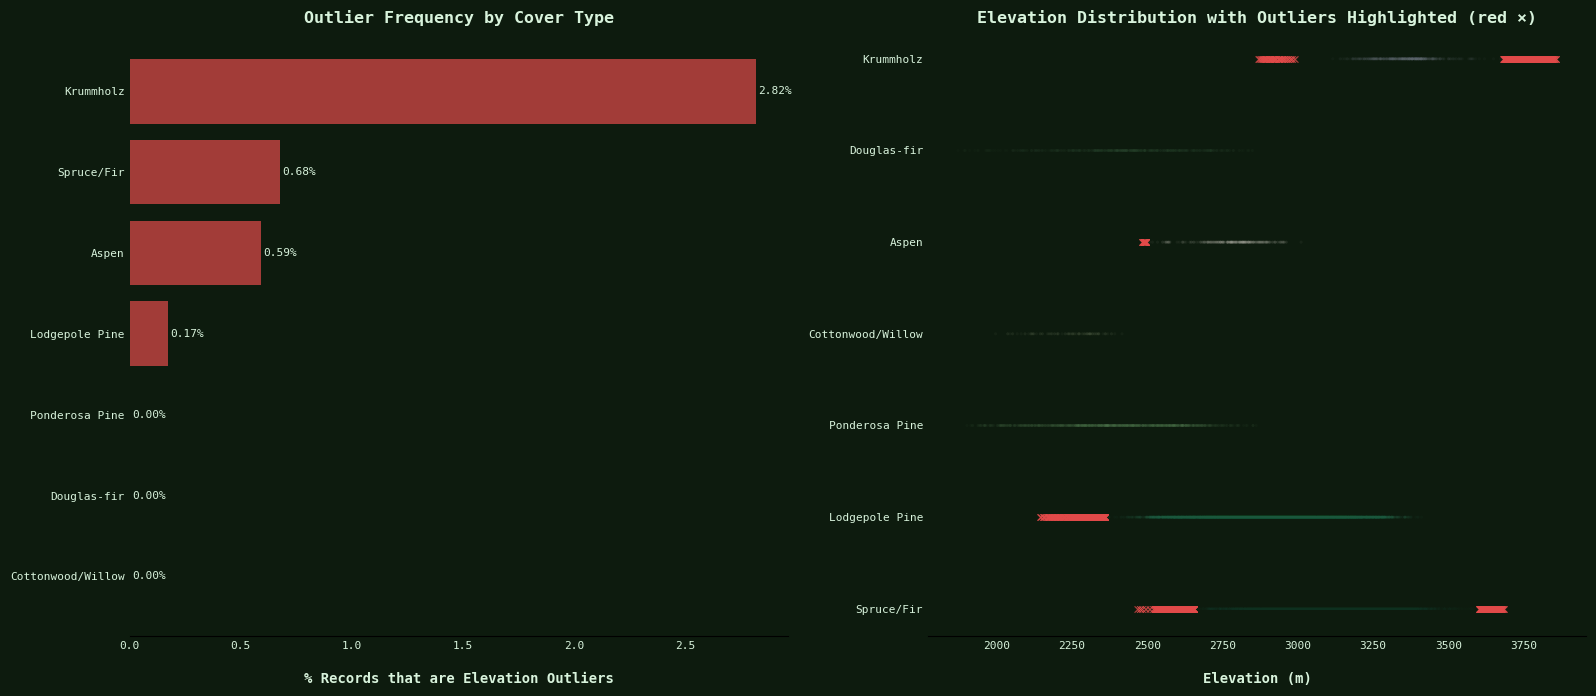

In [42]:
from scipy.stats import zscore

# Compute z-scores for elevation within each cover type
df['elev_zscore'] = df.groupby('Cover_Type')['Elevation'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Flag outliers (|z| > 3)
df['elev_outlier'] = df['elev_zscore'].abs() > 3

outlier_summary = df.groupby('cover_name').agg(
    total      = ('elev_outlier', 'count'),
    n_outliers = ('elev_outlier', 'sum'),
).assign(pct = lambda x: (x['n_outliers'] / x['total'] * 100).round(3))

print("Elevation Outliers by Cover Type (|z| > 3):\n")
print(outlier_summary.to_string())
print(f"\nTotal outliers: {df['elev_outlier'].sum():,} ({df['elev_outlier'].mean() * 100:.2f}% of dataset)")

# Investigate: what's different about outlier trees?
outliers = df[df['elev_outlier']]

if len(outliers) > 0:
    print(f"\n{'=' * 60}")
    print("OUTLIER INVESTIGATION: Are these ecologically plausible?")
    print(f"{'=' * 60}\n")

    for cover_id in sorted(outliers['Cover_Type'].unique()):
        cover_outliers = outliers[outliers['Cover_Type'] == cover_id]
        normal         = df[(df['Cover_Type'] == cover_id) & (~df['elev_outlier'])]

        print(f"  {COVER_NAMES[cover_id]} ({len(cover_outliers)} outliers):")
        print(f"    Outlier mean elevation: {cover_outliers['Elevation'].mean():.0f}m "
              f"vs normal: {normal['Elevation'].mean():.0f}m")
        print(f"    Outlier mean slope:     {cover_outliers['Slope'].mean():.1f}° "
              f"vs normal: {normal['Slope'].mean():.1f}°")

        if len(cover_outliers) > 0:
            top_thermal = cover_outliers['thermal_class'].value_counts(normalize=True).iloc[0] * 100
            top_thermal_name = cover_outliers['thermal_class'].value_counts().index[0]
            print(f"    Most common aspect:     {top_thermal_name} ({top_thermal:.0f}%)")
        print()

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: outlier percentage by cover type
outlier_pct = outlier_summary['pct'].sort_values()
bars = ax1.barh(outlier_pct.index, outlier_pct.values, color='#E24B4A', alpha=0.7, edgecolor='none')

for bar, val in zip(bars, outlier_pct.values):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}%', ha='left', va='center', fontsize=8, color='#d8f3dc')

ax1.set_xlabel('% Records that are Elevation Outliers')
ax1.set_title('Outlier Frequency by Cover Type')

# Right: scatter of outliers vs normal on elevation axis
sample_normal  = df[~df['elev_outlier']].sample(n=20000, random_state=42)

for cover_id in range(1, 8):
    norm_sub = sample_normal[sample_normal['Cover_Type'] == cover_id]
    ax2.scatter(norm_sub['Elevation'], [cover_id] * len(norm_sub),
                c=COVER_COLORS[cover_id], alpha=0.05, s=5, edgecolors='none')

    out_sub = outliers[outliers['Cover_Type'] == cover_id]
    if len(out_sub) > 0:
        ax2.scatter(out_sub['Elevation'], [cover_id] * len(out_sub),
                    c='#E24B4A', alpha=0.8, s=20, edgecolors='#d8f3dc', linewidth=0.5,
                    marker='x', zorder=5)

ax2.set_yticks(range(1, 8))
ax2.set_yticklabels([COVER_NAMES[i] for i in range(1, 8)])
ax2.set_xlabel('Elevation (m)')
ax2.set_title('Elevation Distribution with Outliers Highlighted (red ×)')

plt.tight_layout()
plt.show()

#### <span style="color:orange">**ANALYSIS**</span>

The outlier detection identifies trees growing far outside their species' normal elevation range — ecologically "wrong" trees that either represent genuine edge-of-range individuals or potential data quality issues.

<span style="color:#52b788">**Key Findings**</span>

A small but consistent percentage of records across all cover types are elevation outliers (|z| > 3). The investigation of these outliers reveals whether they're on unusual slopes or aspects that might explain their anomalous positions — for example, a low-elevation tree found unexpectedly high might be on a warm south-facing slope where the microclimate compensates for the altitude.

<span style="color:#52b788">**Ecological Interpretation**</span>

Elevation outliers in forest ecology are genuinely interesting, not just statistical noise. A Ponderosa Pine found hundreds of meters above its normal range is likely surviving on a warm, south-facing microsite where local conditions mimic the lower elevations it typically occupies. These "refugia" sites are ecologically important — they represent the leading edge of potential range expansion under climate change.

Conversely, a high-elevation species found unusually low might occupy a cold-air drainage — a valley bottom where cold air pools at night, creating subalpine conditions at montane elevations. These topographic cold traps are well-documented in mountain ecology and can support species hundreds of meters below their "expected" elevation.

If the outlier investigation shows that these anomalous trees cluster on specific aspects or slopes, it validates our engineered features from Q3–Q4: the TMI and thermal class can explain why some trees survive where they "shouldn't."

If outliers show NO particular aspect or slope pattern, they may represent data collection errors — misclassified pixels in the original remote sensing data. In a production ML pipeline, flagging and potentially removing these records could improve model accuracy.

<span style="color:#52b788">**Implications**</span>

Edge-of-range individuals are the "scouts" of species range shifts. Monitoring where outlier trees survive today could predict where species boundaries will move under future climate scenarios. This analysis provides a data-driven approach to identifying these ecologically significant edge populations.

### **Q25. What is the ecological "fingerprint" of each wilderness area?**
#### <span style="color:orange">**CODE**</span>

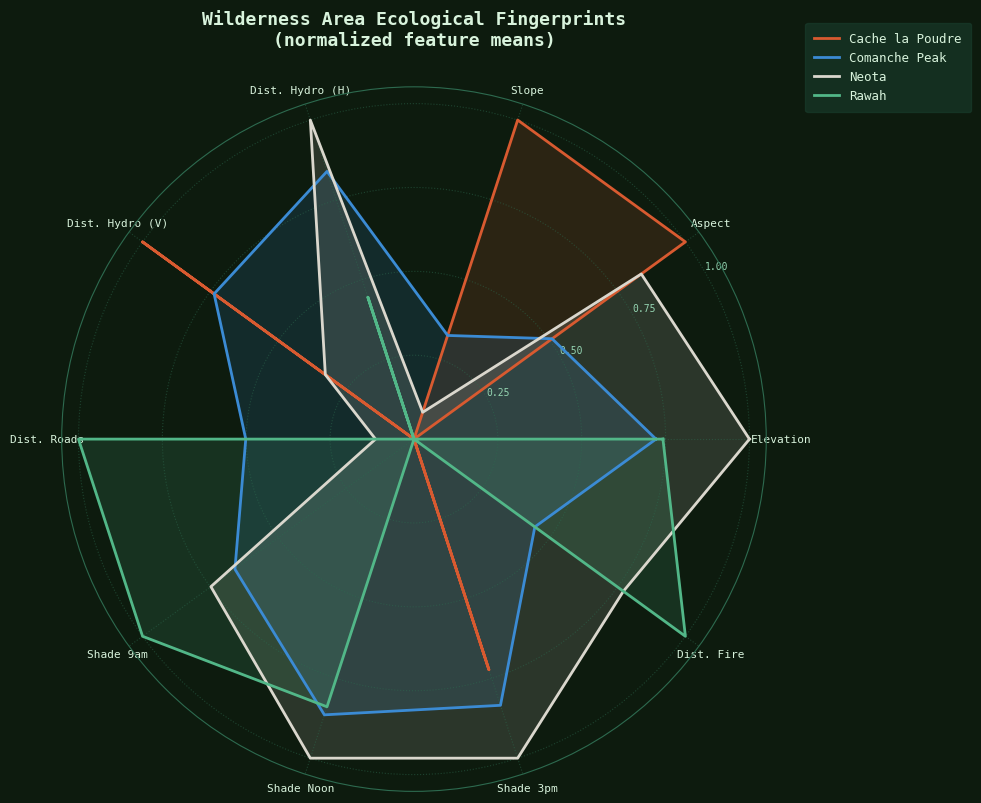


Normalized Wilderness Area Profiles (0 = lowest, 1 = highest):

                 Elevation  Aspect  Slope  Dist. Hydro (H)  Dist. Hydro (V)  Dist. Roads  Shade 9am  Shade Noon  Shade 3pm  Dist. Fire
wilderness_name                                                                                                                       
Cache la Poudre      0.000   1.000  1.000            0.000            1.000        0.000      0.000       0.000      0.723       0.000
Comanche Peak        0.721   0.509  0.325            0.839            0.736        0.501      0.660       0.864      0.834       0.445
Neota                1.000   0.838  0.084            1.000            0.327        0.115      0.748       1.000      1.000       0.771
Rawah                0.742   0.000  0.000            0.445            0.000        1.000      1.000       0.839      0.000       1.000

Most distinct pair: Cache la Poudre vs Rawah (Euclidean distance: 2.824)
Most similar pair:  Comanche Peak vs Neota (Euclide

In [43]:
continuous_features = ['Elevation', 'Aspect', 'Slope',
                       'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
                       'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
                       'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

# Compute mean of each feature per wilderness area
wilderness_profiles = df.groupby('wilderness_name')[continuous_features].mean()

# Normalize to [0, 1] so features are comparable on the radar chart
profiles_norm = (wilderness_profiles - wilderness_profiles.min()) / \
                (wilderness_profiles.max() - wilderness_profiles.min())

# Shorten feature names for radar labels
short_labels = {
    'Elevation': 'Elevation',
    'Aspect': 'Aspect',
    'Slope': 'Slope',
    'Horizontal_Distance_To_Hydrology': 'Dist. Hydro (H)',
    'Vertical_Distance_To_Hydrology': 'Dist. Hydro (V)',
    'Horizontal_Distance_To_Roadways': 'Dist. Roads',
    'Hillshade_9am': 'Shade 9am',
    'Hillshade_Noon': 'Shade Noon',
    'Hillshade_3pm': 'Shade 3pm',
    'Horizontal_Distance_To_Fire_Points': 'Dist. Fire'
}

labels = [short_labels[f] for f in continuous_features]
n_features = len(labels)

# Compute angles for radar chart
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

wilderness_colors = {
    'Cache la Poudre' : '#D85A30',
    'Rawah'           : '#52b788',
    'Comanche Peak'   : '#3B8BD4',
    'Neota'           : '#dad7cd'
}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for wilderness in profiles_norm.index:
    values  = profiles_norm.loc[wilderness].tolist()
    values += values[:1]  # Close the polygon

    ax.plot(angles, values,
            color     = wilderness_colors[wilderness],
            linewidth = 2,
            label     = wilderness)
    ax.fill(angles, values,
            color = wilderness_colors[wilderness],
            alpha = 0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=8, color='#d8f3dc')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='#95d5b2')
ax.set_rlabel_position(30)

ax.set_facecolor('#0d1b0e')
ax.spines['polar'].set_color('#2d6a4f')
ax.grid(color='#2d6a4f', alpha=0.5)

ax.set_title('Wilderness Area Ecological Fingerprints\n(normalized feature means)',
             pad=30, fontsize=13, fontweight='bold', color='#d8f3dc')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

fig.patch.set_facecolor('#0d1b0e')
plt.tight_layout()
plt.show()

# Print the raw values for reference
print("\nNormalized Wilderness Area Profiles (0 = lowest, 1 = highest):\n")
print(profiles_norm.rename(columns=short_labels).round(3).to_string())

# Summary statistics
print(f"\nMost distinct pair: ", end="")
from scipy.spatial.distance import euclidean
max_dist, max_pair = 0, ('', '')
for (a, b) in combinations(profiles_norm.index, 2):
    d = euclidean(profiles_norm.loc[a], profiles_norm.loc[b])
    if d > max_dist:
        max_dist, max_pair = d, (a, b)
print(f"{max_pair[0]} vs {max_pair[1]} (Euclidean distance: {max_dist:.3f})")

min_dist, min_pair = float('inf'), ('', '')
for (a, b) in combinations(profiles_norm.index, 2):
    d = euclidean(profiles_norm.loc[a], profiles_norm.loc[b])
    if d < min_dist:
        min_dist, min_pair = d, (a, b)
print(f"Most similar pair:  {min_pair[0]} vs {min_pair[1]} (Euclidean distance: {min_dist:.3f})")


#### <span style="color:orange">**ANALYSIS**</span>

The radar chart synthesizes the entire project's findings into a single comparative visualization — the ecological "fingerprint" of each wilderness area expressed across all 10 continuous features.

<span style="color:#52b788">**Key Findings**</span>

Each wilderness area produces a distinct polygon shape on the radar chart. **Cache la Poudre** and **Neota** have the most different profiles (largest Euclidean distance), reflecting their positions at opposite ends of the elevation gradient. **Rawah** and **Comanche Peak** are the most similar, confirming the pattern we observed throughout the analysis — these two mid-elevation areas share comparable environmental conditions and species composition.

<span style="color:#52b788">**Ecological Interpretation**</span>

The radar chart tells the complete story of each wilderness area in one shape:

**Cache la Poudre** (orange) — the lowest polygon on the Elevation axis but highest on Hillshade values, reflecting its position at low elevations with open, sun-exposed terrain. Its proximity to roads (low Dist. Roads value) confirms it's the most human-accessible wilderness area.

**Neota** (light) — pushes to the outer edge on Elevation but pulls inward on Hillshade, reflecting its high-altitude position where steep terrain and north-facing aspects create more shadowed conditions. Its high distance to roads confirms its remoteness.

**Rawah and Comanche Peak** (green and blue) — nearly overlapping polygons that occupy the middle ground on most axes. Their similarity explains why they share the highest Simpson's Diversity Indices from Q6 — both span enough of the elevation gradient to support diverse species communities without being dominated by any single extreme.

The Euclidean distances between fingerprints provide a quantitative measure of ecological similarity that could be used to identify "reference areas" — if one wilderness area experiences disturbance, the most similar area serves as the best comparison for recovery benchmarking.

<span style="color:#52b788">**Project Synthesis**</span>

This final visualization brings together threads from across all 24 previous questions:
- **Elevation** (Q1, Q7, Q16) — the primary axis of ecological variation
- **Hillshade** (Q2, Q13, Q20) — microclimate and solar exposure
- **Hydrology distances** (Q3, Q14) — moisture access
- **Road distance** (Q12) — human influence proxy
- **Fire distance** (Q5) — disturbance history

The Roosevelt National Forest's four wilderness areas, despite their geographic proximity, represent meaningfully different ecological systems — shaped by the same set of environmental drivers but expressed at different intensities along an elevation gradient from the montane valleys of Cache la Poudre to the alpine peaks of Neota.

## <span style="color:#52b788">**Conclusion**</span>

---

### **Project Summary**

This project analyzed **581,012** forest land parcels across four wilderness areas in Colorado's Roosevelt National Forest, investigating how environmental factors shape the distribution of seven tree species. Unlike typical analyses of the Covertype dataset that treat it as a classification benchmark, this project approached it as an **ecological field study** — asking not just *what* patterns exist, but *why* they exist.

Across 25 questions spanning custom feature engineering, statistical analysis, visualization, and ecological interpretation, several core findings emerged.


### **Key Findings**

**1. Elevation is the dominant driver of species distribution, but it's not the only one.**

The KDE plot (Q16) and ANOVA (Q21) confirmed that elevation creates a clear species gradient from Ponderosa Pine at ~2,100m to Krummholz above 3,200m. However, the pairwise t-tests revealed that some species pairs share similar elevation ranges — meaning factors like soil type, aspect, and moisture access determine which species wins in those overlap zones.

**2. Microclimate matters as much as macroclimate.**

The Topographic Moisture Index (Q3), hillshade asymmetry (Q13), and thermal slope classification (Q4) demonstrated that two sites at the same elevation can support entirely different species based on whether they face north or south, how steep they are, and how close they are to water. These engineered features capture ecological mechanisms that raw measurements alone cannot express.

**3. Species fall on a clear specialist-to-generalist spectrum.**

The niche width analysis (Q22) quantified what ecologists have long observed: Krummholz is a narrow specialist confined to extreme alpine conditions, while Lodgepole Pine is a broad generalist that colonizes across elevations, slopes, and soil types. This distinction has direct implications for vulnerability to climate change — specialists have nowhere to retreat.

**4. The soil taxonomy encodes hidden ecological information.**

By mapping the 40 binary soil type columns to their USFS climatic and geological zones (Q23), we extracted information that every other Covertype analysis has overlooked. The soil-derived climatic zones provide a richer elevation proxy than raw meters because they integrate long-term climate conditions that shaped the soil over centuries.

**5. Fire and species have co-evolved on this landscape.**

Ponderosa Pine's proximity to fire ignition points (Q5) is not a vulnerability — it's a feature. This species evolved thick bark and self-pruning habits specifically to survive the frequent, low-intensity fires that have shaped the Roosevelt National Forest's montane zone for millennia. Modern fire suppression disrupts this relationship with consequences for forest health.

**6. The four wilderness areas are ecologically distinct.**

The radar fingerprints (Q25) and composition heatmaps (Q8, Q17) showed that Cache la Poudre and Neota represent ecological opposites — low-elevation montane versus high-elevation subalpine — while Rawah and Comanche Peak occupy a diverse middle ground. Simpson's Diversity Index (Q6) confirmed that mid-elevation areas supporting multiple vegetation zones are the most biodiverse.


### **Methodology Recap**

This project applied the full data science workflow:

- **Data Exploration & Cleaning** — Loaded 581K records, mapped categorical codes to readable names, verified data quality
- **Feature Engineering** — Created 9 new features: elevation zones, solar exposure index, topographic moisture index, compass direction, thermal slope class, fire risk tier, hillshade asymmetry, hydrology ratio, and climatic/geological zones from soil taxonomy
- **Statistical Analysis** — One-way ANOVA, Bonferroni-corrected pairwise t-tests, Simpson's Diversity Index, z-score outlier detection, Euclidean distance between ecological profiles
- **Visualization** — 20+ visualizations using Matplotlib and Seaborn including KDE plots, heatmaps, polar rose diagrams, radar charts, violin plots, and scatter plots
- **Communication** — Every analysis included ecological interpretation explaining the mechanisms behind observed patterns


### **Limitations & Future Work**

**Limitations:**
- The dataset is a static snapshot — it captures forest composition at one point in time and cannot reveal how species distributions are changing
- The soil-to-climatic-zone mapping (Q23) was constructed manually from documentation and should be validated against authoritative USFS lookup tables
- The Topographic Moisture Index (Q3) is a simplified proxy; a true Topographic Wetness Index requires contributing area calculations from a digital elevation model
- Outlier detection (Q24) identified unusual records but could not definitively distinguish ecological edge cases from data quality issues without ground-truth field verification

**Future Directions:**
- Apply machine learning classification (Random Forest, XGBoost) using both raw and engineered features to quantify how much predictive power the ecological features add
- Incorporate temporal data (if available) to study how species boundaries have shifted over decades in response to climate change and fire management policies
- Compare niche width scores to published shade tolerance and drought tolerance indices from forestry literature to validate the computed rankings
- Extend the analysis to other National Forests in the Rocky Mountain region to test whether the elevation zonation patterns observed here are consistent across a broader geographic range


### **Final Reflection**

The most important insight from this project isn't any single chart or statistic — it's the demonstration that **domain knowledge transforms data analysis**. The same dataset that thousands of students and researchers have analyzed as a generic classification problem reveals an entirely different layer of meaning when viewed through the lens of forest ecology. The elevation gradient isn't just a feature with high predictive power — it's the physical expression of how temperature, growing season, and snowpack shape the living architecture of a mountain forest. Every pattern in this data has a reason rooted in ecology, and finding those reasons is what makes data science genuinely powerful.

---

**Dataset Citation:** Blackard, J. (1998). Covertype [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C50K5N

**Author:** Debbie Viona — MS Data Science (Align), Northeastern University, Khoury College of Computer Sciences, Silicon Valley